# Turbofan Engine RUL Prediction — C-MAPSS (FD001–FD004)

This notebook builds a two-stage machine learning pipeline to predict the
**Remaining Useful Life (RUL)** of aircraft turbofan engines using the NASA
C-MAPSS dataset.

**Pipeline overview:**
1. Load and label all 4 sub-datasets (FD001–FD004)
2. Explore the data (EDA)
3. Engineer features: operating-condition clustering, per-condition scaling,
   dead-sensor removal, outlier removal, PCA
4. Train **Stage 1** — a classifier that flags an engine as `healthy` vs
   `degrading`
5. Train **Stage 2** — a regressor that predicts the actual RUL, but only for
   engines Stage 1 flagged as `degrading` (healthy engines are simply
   reported at the RUL cap)
6. Evaluate the full two-stage pipeline end-to-end and save the trained
   models.


## 1. Imports & Setup

All libraries used anywhere in the notebook, grouped by purpose:
- **Data handling:** pandas, numpy, os, joblib (saving models)
- **Visualization:** matplotlib, seaborn
- **Preprocessing / unsupervised:** StandardScaler, KMeans, PCA
- **Stage 1 (classification) candidates:** Logistic Regression, SVM, KNN,
  Naive Bayes, Decision Tree, Random Forest, AdaBoost, Gradient Boosting
- **Stage 2 (regression) candidates:** Linear Regression, SVR, KNN, Decision
  Tree, Random Forest, AdaBoost, Gradient Boosting
- **Metrics:** classification_report, f1_score, mean_squared_error


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from collections import Counter

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

import joblib   # GUI


## 2. Configuration & Column Definitions

Defines the constants used everywhere downstream: the 4 sub-dataset names,
the RUL cap (a standard trick for this dataset — see Phase 3), and the
column names for the raw 26-column text files (no header row in the raw
files, so we assign names ourselves).


In [ ]:
dataset = ['FD001', 'FD002', 'FD003', 'FD004']
rul_cap = 125
index_cols = ['unit_number', 'time_cycles']
setting_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
all_cols = index_cols + setting_cols + sensor_cols


## 3. Data Loading Functions

Three helper functions:
- `load_raw` — reads one raw, whitespace-separated, headerless text file and
  attaches the proper column names.
- `compute_train_rul` — for **training** data: since training engines run
  all the way to failure, RUL for any row is simply *(that engine's last
  cycle) − (this row's cycle)*, then capped at `rul_cap`.
- `compute_test_rul` — for **test** data: test engines are cut off *before*
  failure, so we don't know the true RUL directly. NASA provides a separate
  `RUL_FDxxx.txt` file with "how many cycles were left when the recording
  stopped" for each test engine — we add that onto *(engine's last recorded
  cycle in the file) − (this row's cycle)* to reconstruct the true RUL at
  every row, then cap it the same way.


In [ ]:
def load_raw(path):
    data = pd.read_csv(path, sep=r'\s+', header=None)
    data = data.iloc[:, :26]
    data.columns = all_cols
    return data

def compute_train_rul(data):
    max_cycle = data.groupby('unit_number')['time_cycles'].transform('max')
    data['rul'] = max_cycle - data['time_cycles']
    data['rul'] = data['rul'].clip(upper=rul_cap)
    return data

def compute_test_rul(data, rul_path):
    true_rul_at_end = pd.read_csv(rul_path, header=None, names=['rul_end'])
    true_rul_at_end['unit_number'] = true_rul_at_end.index + 1
    max_cycle = data.groupby('unit_number')['time_cycles'].max().reset_index()
    max_cycle.columns = ['unit_number', 'max_cycle']
    data = data.merge(max_cycle, on='unit_number', how='left')
    data = data.merge(true_rul_at_end, on='unit_number', how='left')
    data['rul'] = data['rul_end'] + (data['max_cycle'] - data['time_cycles'])
    data['rul'] = data['rul'].clip(upper=rul_cap)
    data = data.drop(columns=['max_cycle', 'rul_end'])
    return data


## 4. Load & Combine All Sub-Datasets

Loops over all 4 sub-datasets, loads train + test, computes RUL for each,
tags each row with which sub-dataset it came from and how many operating
conditions / fault modes that sub-dataset has, then concatenates everything
into two big dataframes: `train_all` and `test_all`.

Also builds `global_unit_id` (e.g. `"FD002_37"`), because `unit_number`
alone repeats across sub-datasets (engine 1 exists in FD001 *and* FD002 *and*
FD003...) — without this, later groupby/split operations would wrongly mix
rows from different engines that happen to share the same number.


In [ ]:
import os

DATA_DIR = '/content'
train_frames = []
test_frames = []

for ds in dataset:
    train_df = load_raw(os.path.join(DATA_DIR, f'train_{ds}.txt'))
    train_df = compute_train_rul(train_df)
    train_df['dataset'] = ds
    train_df['n_conditions'] = 6 if ds in ['FD002', 'FD004'] else 1
    train_df['n_fault_modes'] = 2 if ds in ['FD003', 'FD004'] else 1
    train_frames.append(train_df)

    test_df = load_raw(os.path.join(DATA_DIR, f'test_{ds}.txt'))
    test_df = compute_test_rul(test_df, os.path.join(DATA_DIR, f'RUL_{ds}.txt'))
    test_df['dataset'] = ds
    test_df['n_conditions'] = 6 if ds in ['FD002', 'FD004'] else 1
    test_df['n_fault_modes'] = 2 if ds in ['FD003', 'FD004'] else 1
    test_frames.append(test_df)

train_all = pd.concat(train_frames, ignore_index=True)
test_all = pd.concat(test_frames, ignore_index=True)
train_all['global_unit_id'] = train_all['dataset'] + '_' + train_all['unit_number'].astype(str)
test_all['global_unit_id'] = test_all['dataset'] + '_' + test_all['unit_number'].astype(str)


## 5. Initial Data Overview

Basic sanity checks before doing any real analysis: shapes, a preview of
both dataframes, missing values, dtypes, and summary statistics.

> REVIEW (opinion): several cells in the original notebook repeat the same
> check twice (e.g. shape is printed here, then printed again two cells
> later on its own). I've flagged the exact-duplicates below — safe to
> delete, they don't add anything the first check didn't already show.


In [ ]:
print("Train shape:", train_all.shape)
print("Test shape:", test_all.shape)
print(train_all['dataset'].value_counts())


Train shape: (160359, 31)
Test shape: (104897, 31)
dataset
FD004    61249
FD002    53759
FD003    24720
FD001    20631
Name: count, dtype: int64


In [ ]:
train_all.head()


,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul,dataset,n_conditions,n_fault_modes,global_unit_id
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,392,2388,100.0,39.06,23.4190,125,FD001,1,1,FD001_1
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,392,2388,100.0,39.00,23.4236,125,FD001,1,1,FD001_1
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,390,2388,100.0,38.95,23.3442,125,FD001,1,1,FD001_1
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,392,2388,100.0,38.88,23.3739,125,FD001,1,1,FD001_1
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,393,2388,100.0,38.90,23.4044,125,FD001,1,1,FD001_1


In [ ]:
test_all.head()


,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul,dataset,n_conditions,n_fault_modes,global_unit_id
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,392,2388,100.0,38.86,23.3735,125,FD001,1,1,FD001_1
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,393,2388,100.0,39.02,23.3916,125,FD001,1,1,FD001_1
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,393,2388,100.0,39.08,23.4166,125,FD001,1,1,FD001_1
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,391,2388,100.0,39.00,23.3737,125,FD001,1,1,FD001_1
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,390,2388,100.0,38.99,23.4130,125,FD001,1,1,FD001_1


In [ ]:
train_all.nunique()

,0
unit_number,260
time_cycles,543
op_setting_1,670
op_setting_2,111
op_setting_3,2
sensor_1,6
sensor_2,1799
sensor_3,15377
sensor_4,20582
sensor_5,6


In [ ]:
train_all.isnull().sum()


,0
unit_number,0
time_cycles,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [ ]:
train_all.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160359 entries, 0 to 160358
Data columns (total 31 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   unit_number     160359 non-null  int64  
 1   time_cycles     160359 non-null  int64  
 2   op_setting_1    160359 non-null  float64
 3   op_setting_2    160359 non-null  float64
 4   op_setting_3    160359 non-null  float64
 5   sensor_1        160359 non-null  float64
 6   sensor_2        160359 non-null  float64
 7   sensor_3        160359 non-null  float64
 8   sensor_4        160359 non-null  float64
 9   sensor_5        160359 non-null  float64
 10  sensor_6        160359 non-null  float64
 11  sensor_7        160359 non-null  float64
 12  sensor_8        160359 non-null  float64
 13  sensor_9        160359 non-null  float64
 14  sensor_10       160359 non-null  float64
 15  sensor_11       160359 non-null  float64
 16  sensor_12       160359 non-null  float64
 17  sensor_13 

In [ ]:
train_all.describe()


,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul,n_conditions,n_fault_modes
count,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,...,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000
mean,105.553758,123.331338,17.211973,0.410004,95.724344,485.840890,597.361022,1467.035653,1260.956434,9.894999,...,9.054747,0.025185,360.698801,2273.754039,98.389146,25.942709,15.565700,90.182029,4.585954,1.536103
std,72.867325,83.538146,16.527988,0.367938,12.359044,30.420388,42.478516,118.175261,136.300073,4.265554,...,0.751581,0.004997,31.021430,142.513114,4.656270,11.691422,7.015067,41.241036,2.251829,0.498696
min,1.000000,1.000000,-0.008700,-0.000600,60.000000,445.000000,535.480000,1242.670000,1023.770000,3.910000,...,8.156300,0.020000,302.000000,1915.000000,84.930000,10.160000,6.010500,0.000000,1.000000,1.000000
25%,44.000000,57.000000,0.001300,0.000200,100.000000,449.440000,549.960000,1357.360000,1126.830000,5.480000,...,8.439250,0.020000,332.000000,2212.000000,100.000000,14.330000,8.601300,56.000000,1.000000,1.000000
50%,89.000000,114.000000,19.998100,0.620000,100.000000,489.050000,605.930000,1492.810000,1271.740000,9.350000,...,9.030100,0.030000,367.000000,2319.000000,100.000000,24.920000,14.953500,113.000000,6.000000,2.000000
75%,164.000000,173.000000,35.001500,0.840000,100.000000,518.670000,642.340000,1586.590000,1402.200000,14.620000,...,9.344200,0.030000,392.000000,2388.000000,100.000000,38.820000,23.294600,125.000000,6.000000,2.000000
max,260.000000,543.000000,42.008000,0.842000,100.000000,518.670000,645.110000,1616.910000,1441.490000,14.620000,...,11.066900,0.030000,400.000000,2388.000000,100.000000,39.890000,23.950500,125.000000,6.000000,2.000000


In [ ]:
train_all.dtypes.value_counts()


,count
float64,22
int64,7
object,2


## 6. EDA — Raw Sensor Distributions & Correlations (before scaling)

Looks at each sensor's spread (coefficient of variation, histograms) and how
sensors correlate with each other, **before** any per-condition scaling has
been applied. The correlation heatmap here is explicitly noted (by the
original author) as misleading, since all engines are mixed together across
very different operating conditions at this point.


In [ ]:
for col in all_cols:
    print(f"{col}: coff_of_var : {(train_all[col].std())/(train_all[col].mean())}")
    print("______________________________")


unit_number: coff_of_var : 0.690333784859847
______________________________
time_cycles: coff_of_var : 0.6773472745471069
______________________________
op_setting_1: coff_of_var : 0.9602611081415616
______________________________
op_setting_2: coff_of_var : 0.897402336571944
______________________________
op_setting_3: coff_of_var : 0.12911077539562113
______________________________
sensor_1: coff_of_var : 0.06261389021390512
______________________________
sensor_2: coff_of_var : 0.07111029163352074
______________________________
sensor_3: coff_of_var : 0.08055377545484865
______________________________
sensor_4: coff_of_var : 0.10809261054682066
______________________________
sensor_5: coff_of_var : 0.4310818329136473
______________________________
sensor_6: coff_of_var : 0.4467210591517866
______________________________
sensor_7: coff_of_var : 0.48406819192262296
______________________________
sensor_8: coff_of_var : 0.06263732629678204
______________________________
sensor_9: coff_

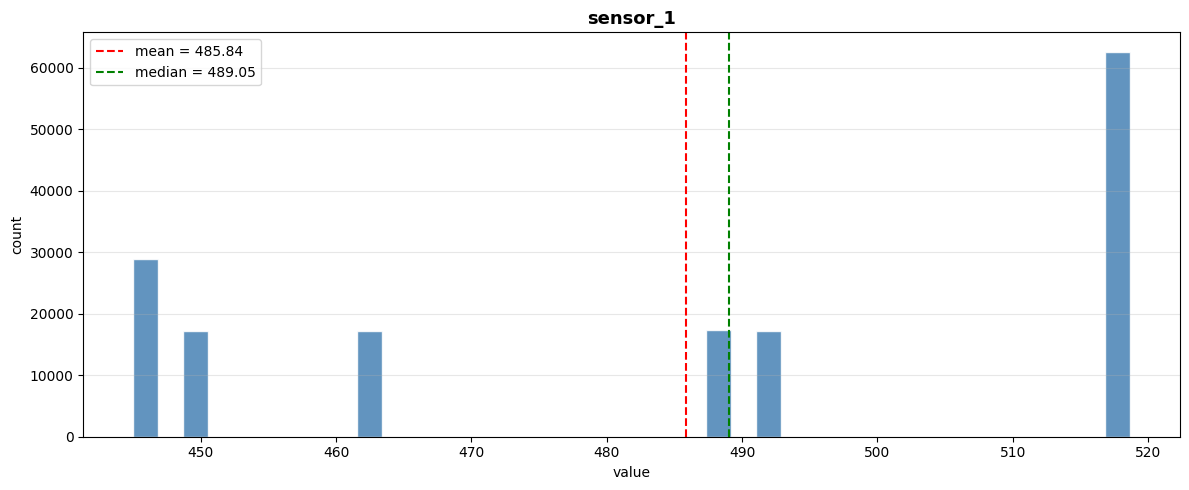

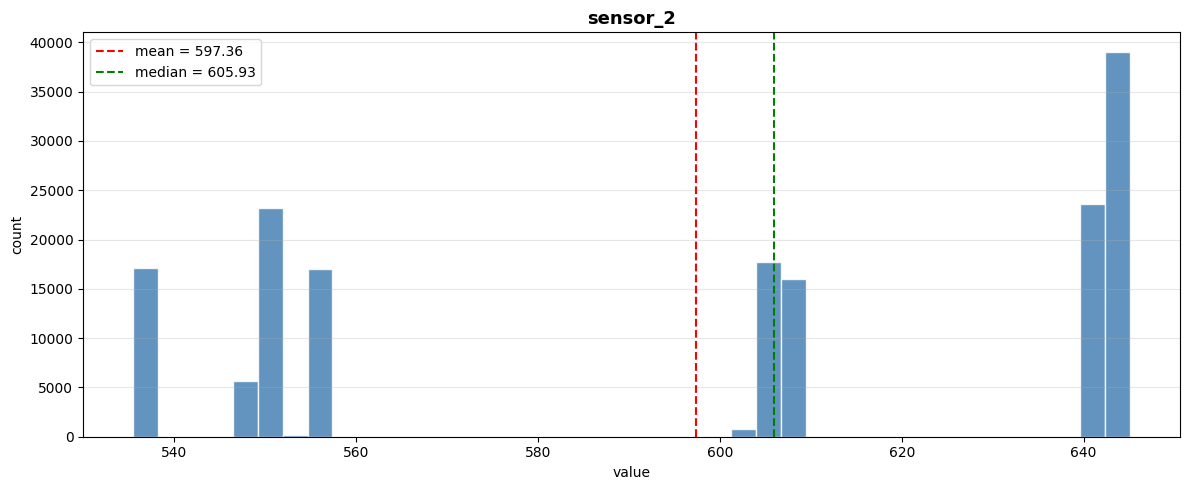

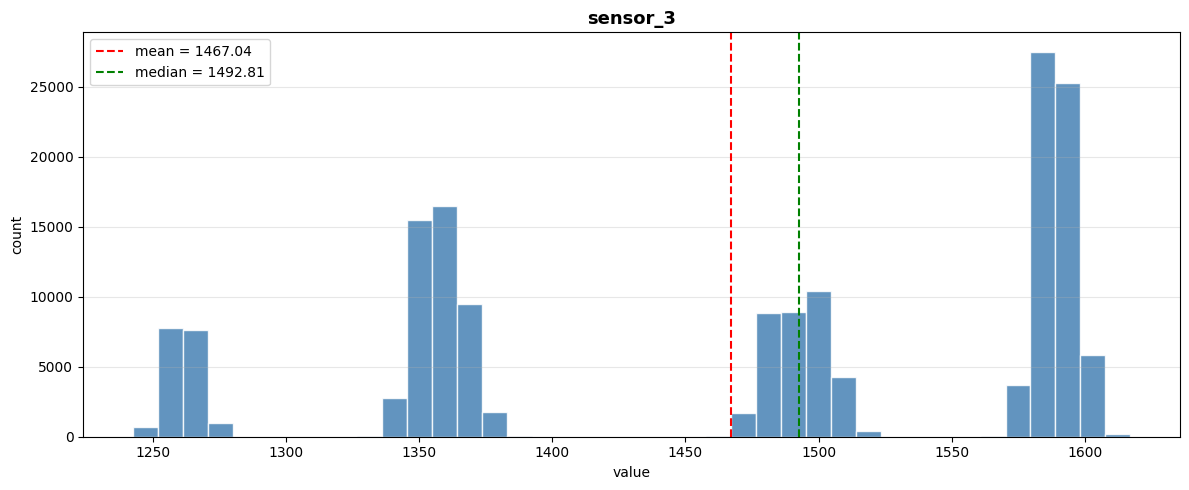

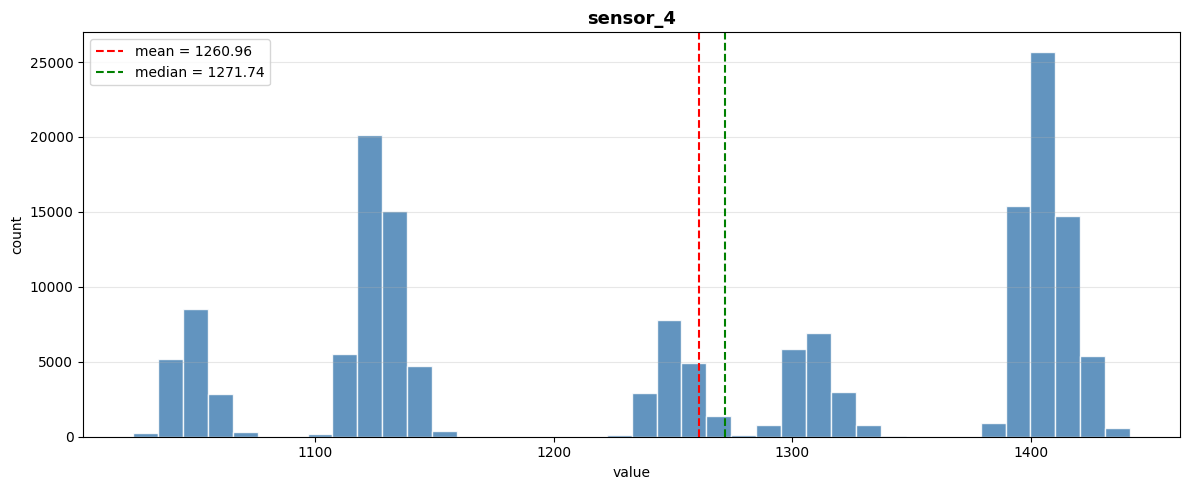

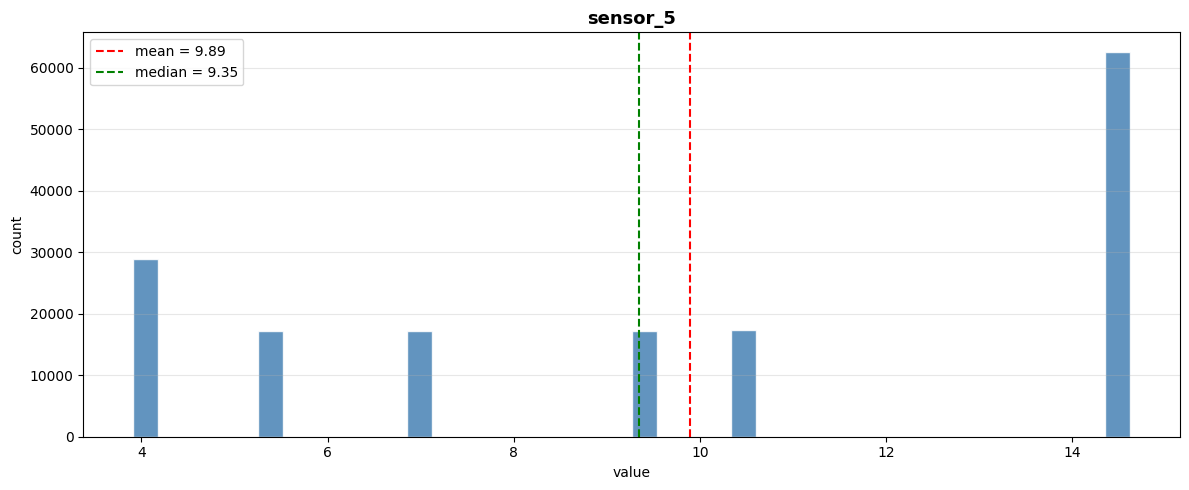

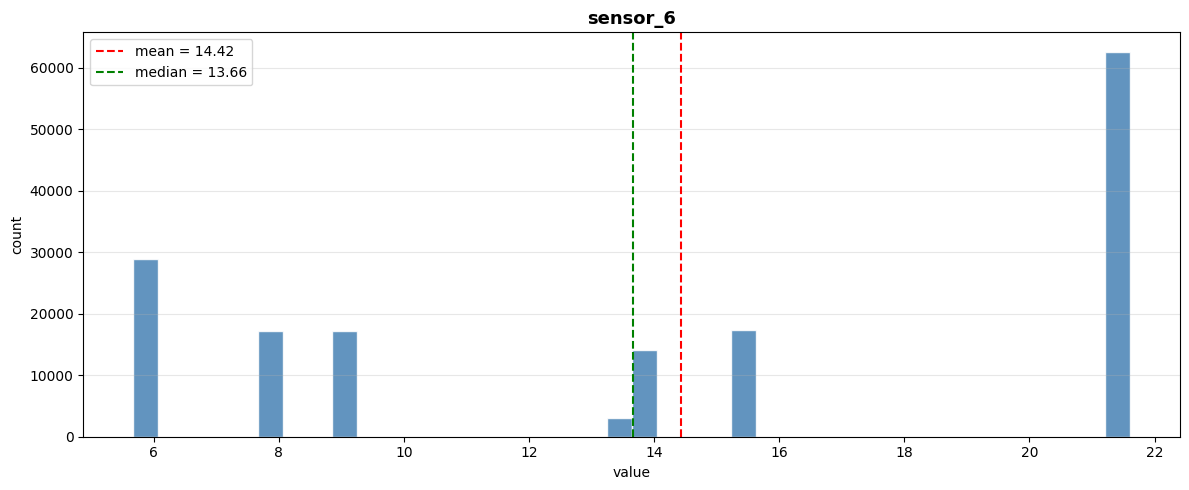

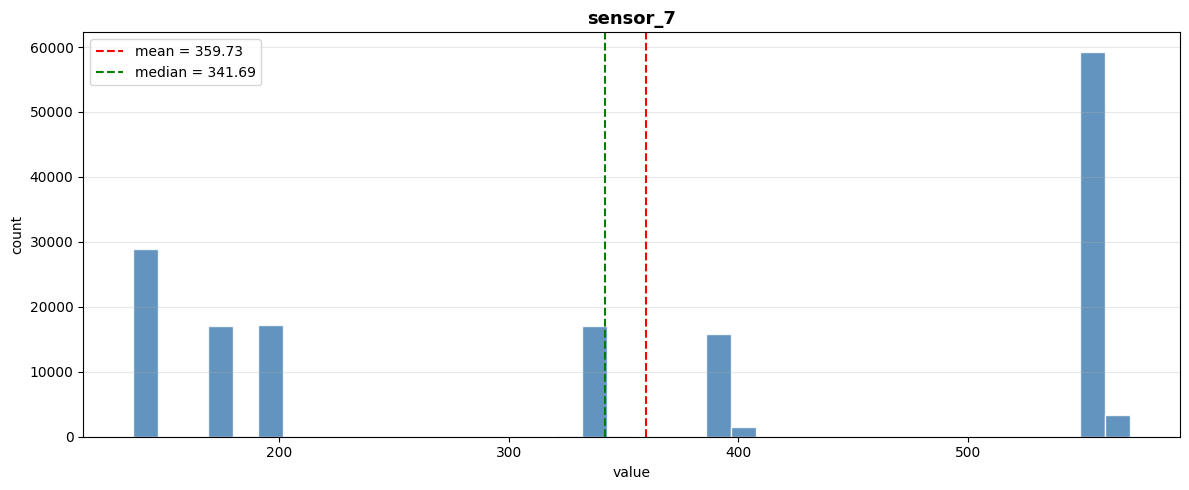

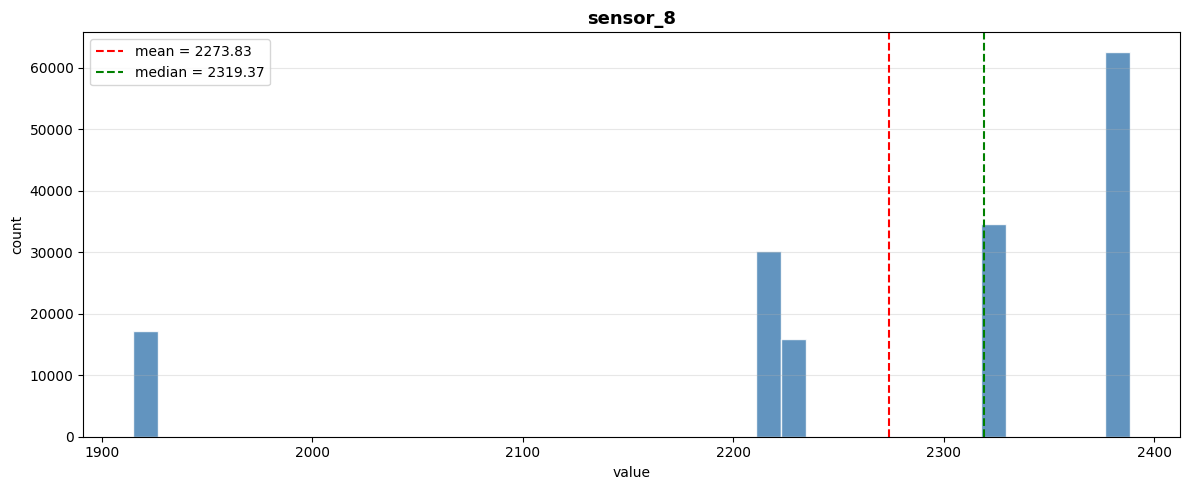

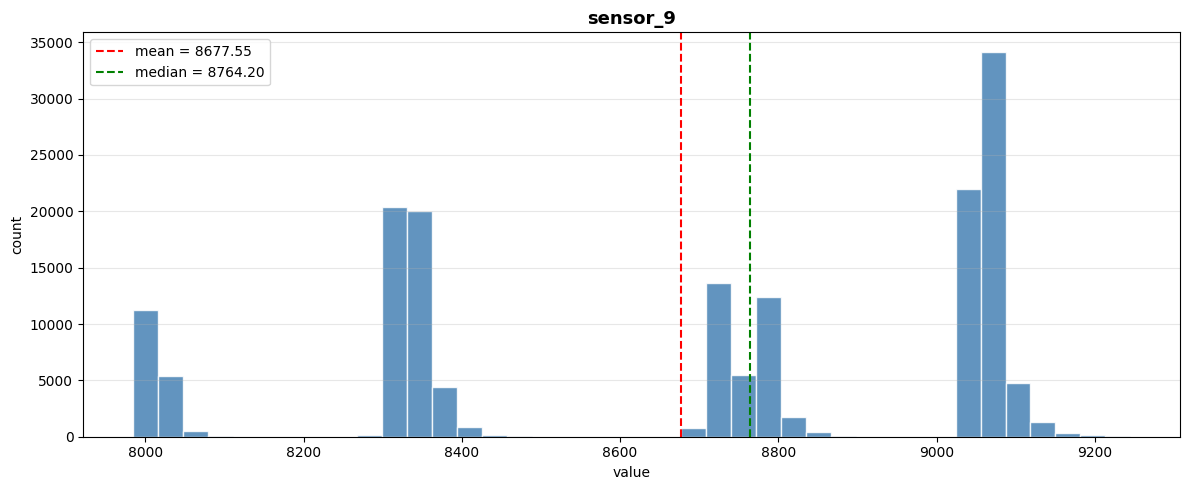

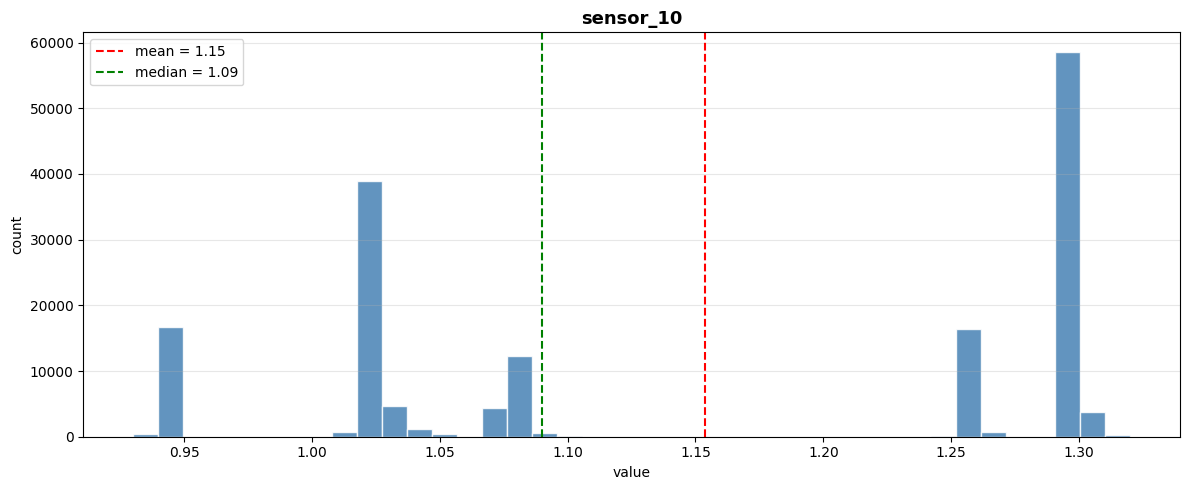

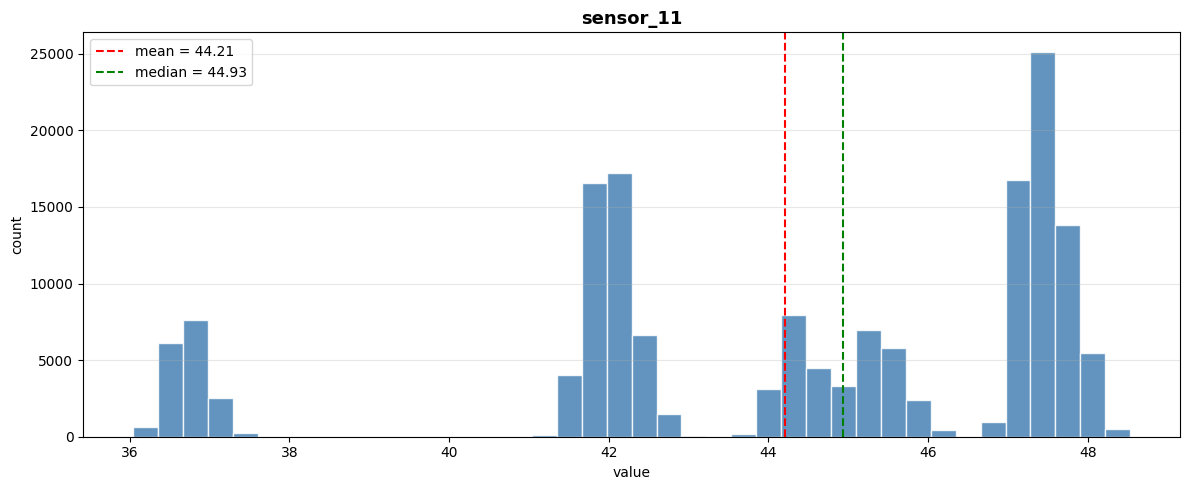

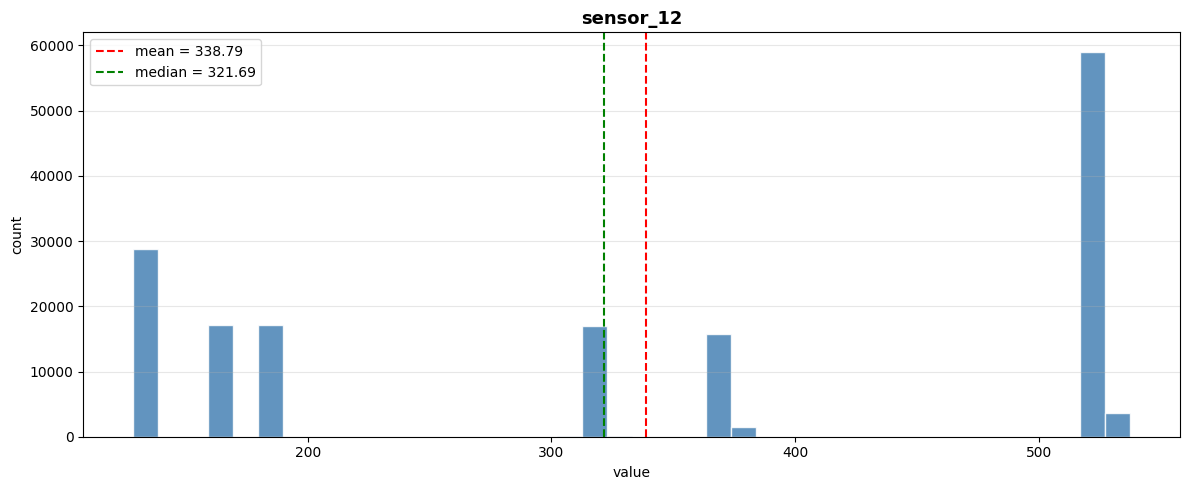

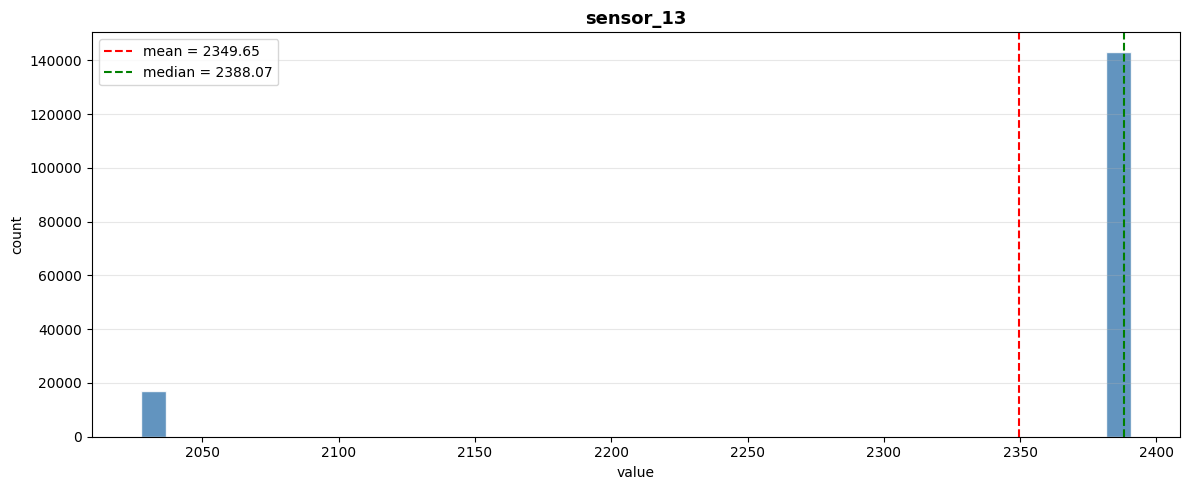

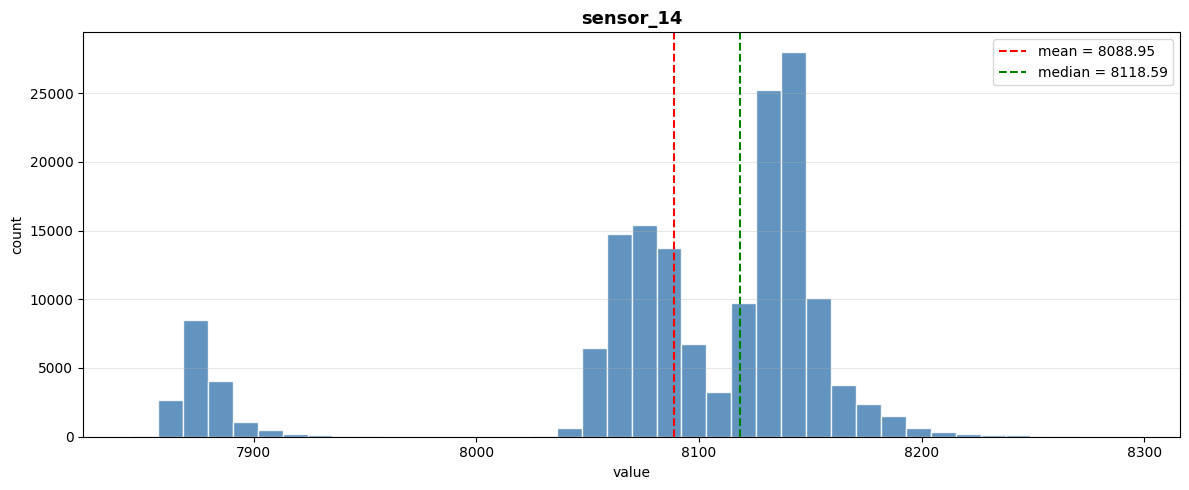

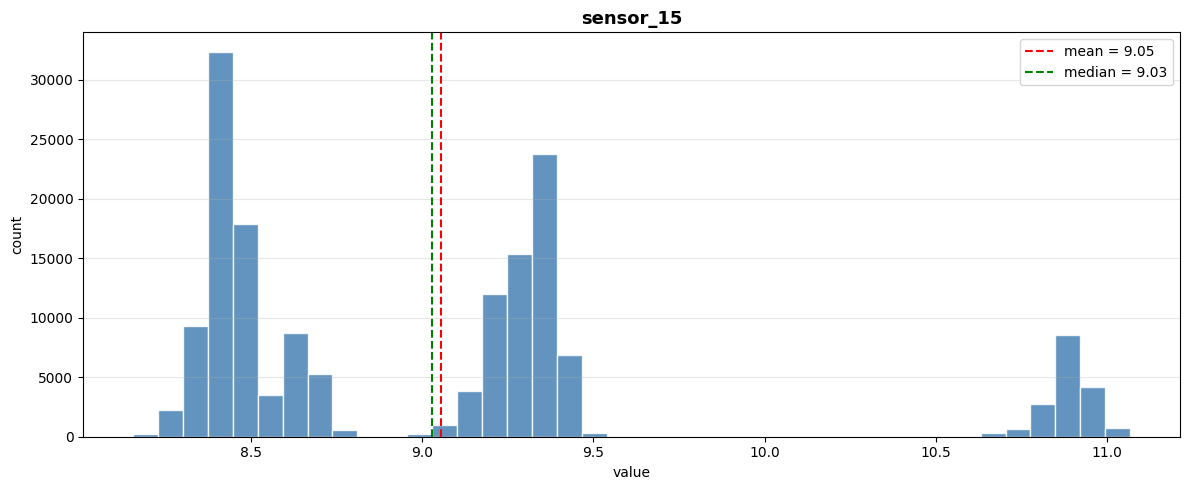

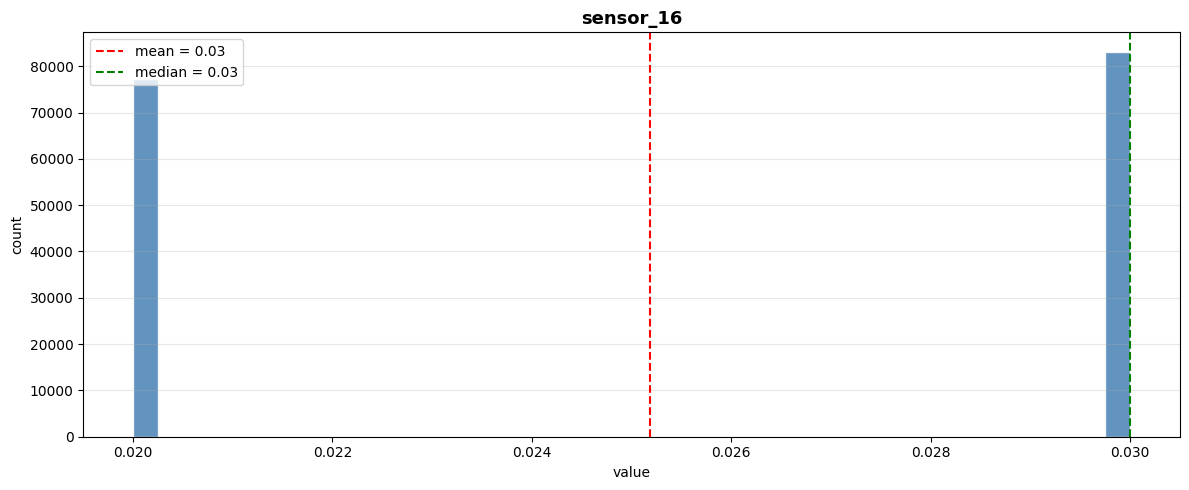

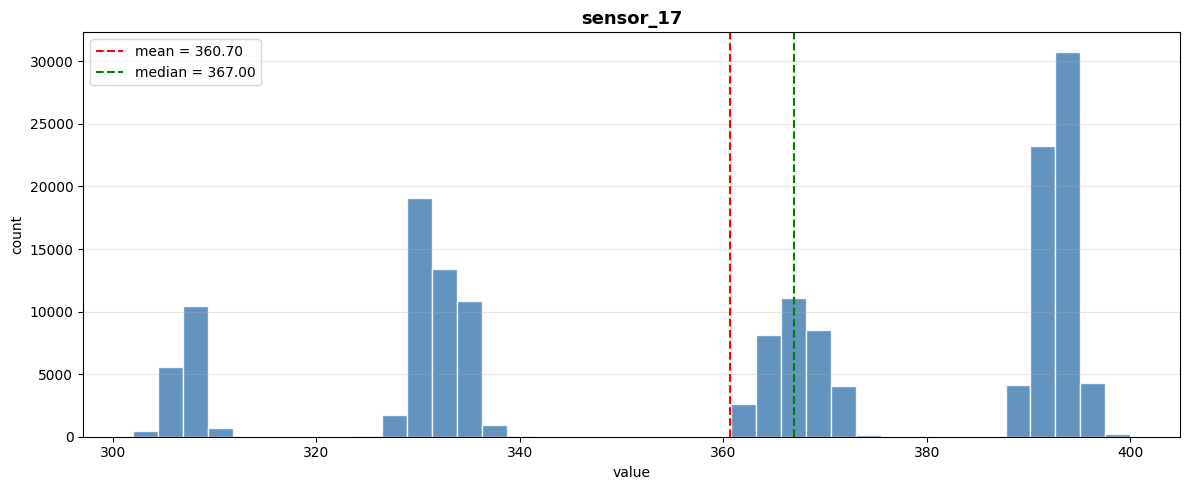

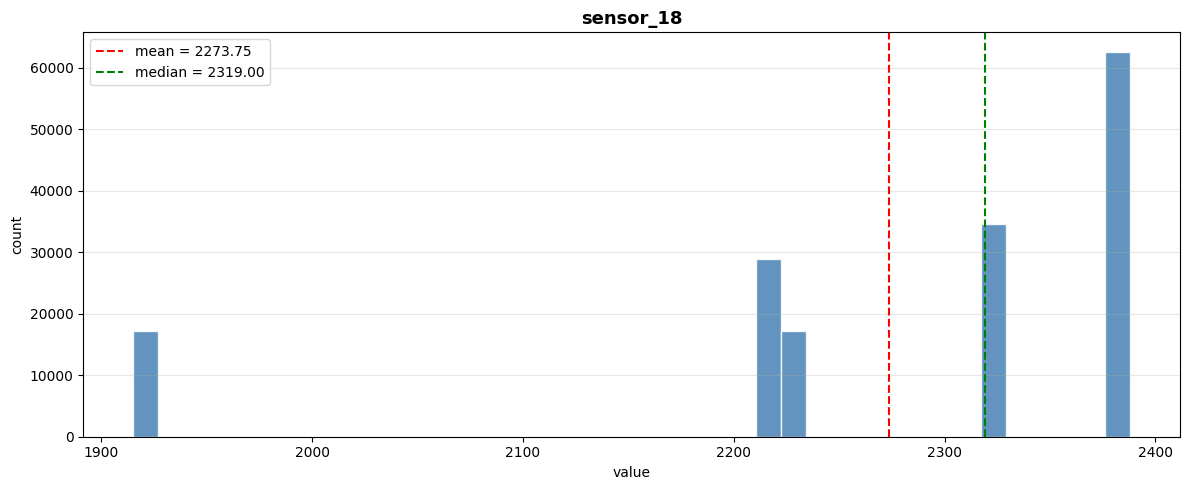

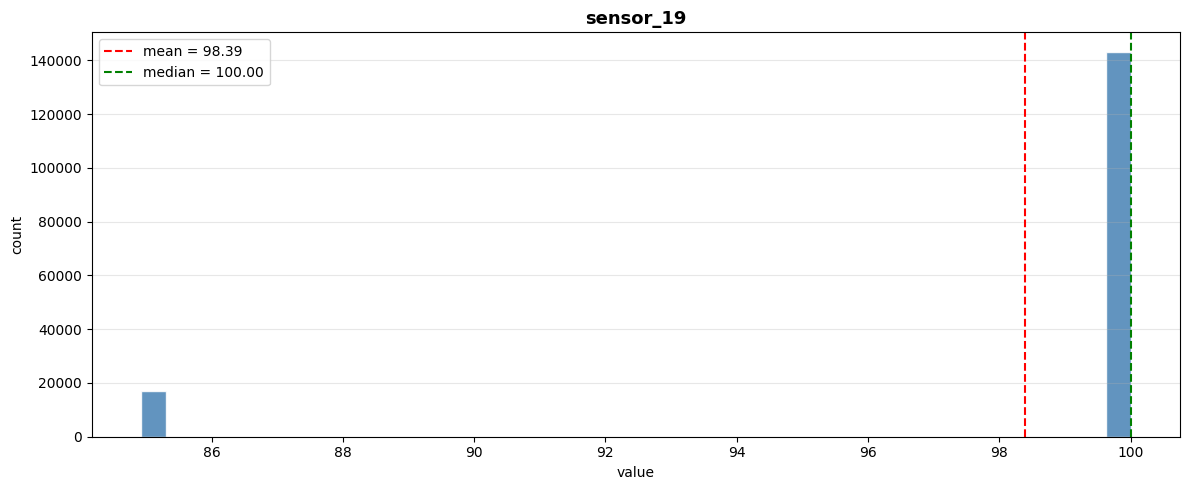

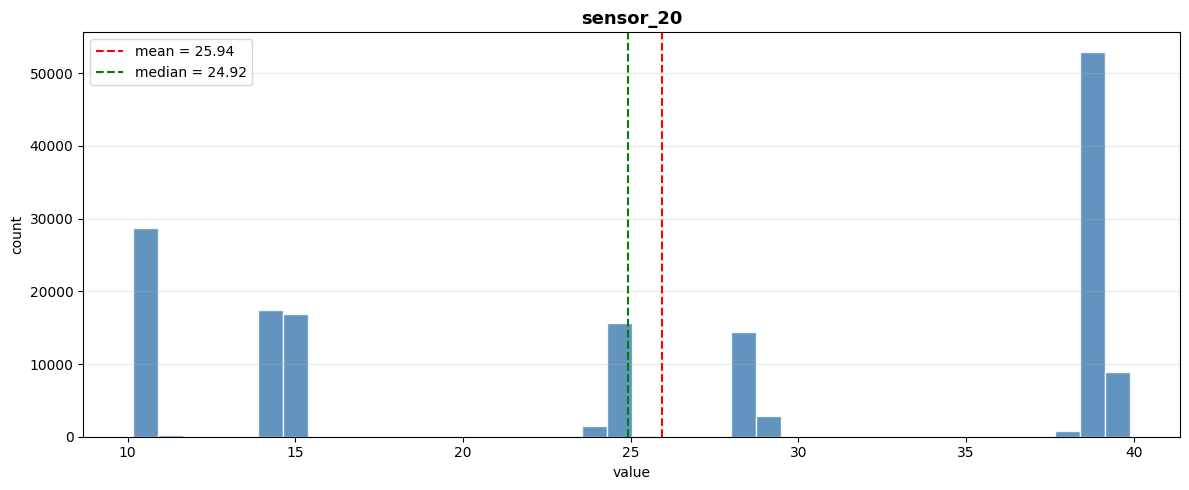

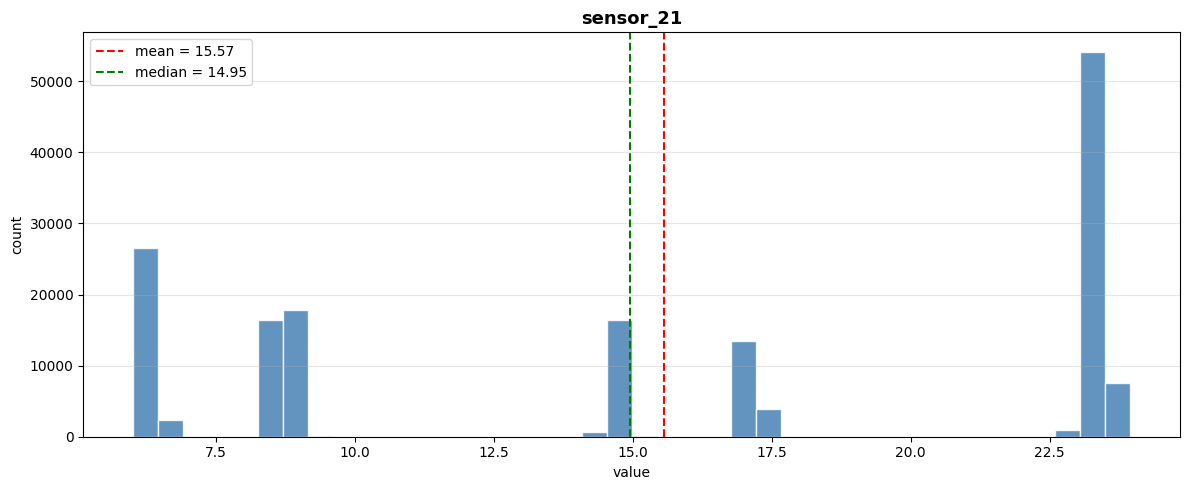

In [ ]:
for col in sensor_cols:
    plt.figure(figsize=(12, 5))
    plt.hist(train_all[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)   # distribution of this sensor's raw readings

    mean_val = train_all[col].mean()
    median_val = train_all[col].median()
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'mean = {mean_val:.2f}')     # mark the mean
    plt.axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'median = {median_val:.2f}')  # mark the median

    plt.title(col, fontsize=13, fontweight='bold')
    plt.xlabel('value')
    plt.ylabel('count')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

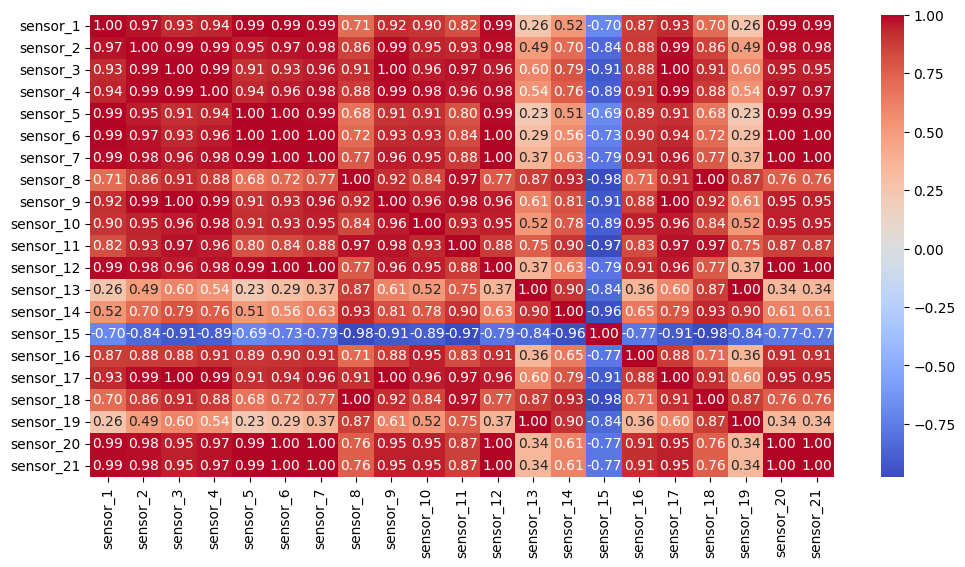

In [ ]:
corr = train_all[sensor_cols].corr(numeric_only=True)
plt.figure(figsize=(12,6))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.show



## 7. Feature Engineering — Fix Dtypes & Detect Operating Conditions

Two things happen here:
1. Make sure sensor columns are `float` (defensive — some got read as
   generic/object types).
2. For FD002/FD004 (the 6-condition datasets), use **KMeans** on the 3
   operational settings to assign each row one of 6 discrete
   `op_condition` labels. FD001/FD003 only have one condition, so they stay
   at the default `op_condition = 0`.

Note: KMeans is fit **only on training data**, then just applied
(`.predict`, not re-fit) to the test data — this avoids leaking test-set
information into the clustering, which is the right way to do it.


In [ ]:
train_all[sensor_cols]=train_all[sensor_cols].astype(float)
test_all[sensor_cols]=test_all[sensor_cols].astype(float)


In [ ]:
train_all["op_condition"] = 0
test_all["op_condition"] = 0


In [ ]:
mask_train_all = train_all["dataset"].isin(["FD002","FD004"])
mask_test_all = test_all["dataset"].isin(["FD002","FD004"])
kmean = KMeans(n_clusters=6,random_state=111,n_init=10)


In [ ]:
train_all.loc[mask_train_all, 'op_condition'] = kmean.fit_predict(train_all.loc[mask_train_all, setting_cols])


In [ ]:
test_all.loc[mask_test_all, 'op_condition'] = kmean.predict(test_all.loc[mask_test_all, setting_cols])


In [ ]:
train_all["dataset"].unique()


array(['FD001', 'FD002', 'FD003', 'FD004'], dtype=object)

In [ ]:
train_all["op_condition"].unique()


array([0, 5, 2, 1, 3, 4])

## 8. Feature Engineering — Scale Sensors Per (Dataset, Operating Condition)

Fits a separate `StandardScaler` for every `(dataset, op_condition)`
combination, using **training rows only**, then applies that same fitted
scaler to the matching test rows. This is important because the same
sensor reads differently depending on operating condition — scaling within
each condition group (rather than globally) removes that condition-driven
shift and leaves the health-related signal.

No leakage here either: each scaler is `fit` on train and only
`.transform`-ed (never re-fit) on test.


In [ ]:
scalers = {}

for fd in train_all["dataset"].unique():
  for cond in train_all["op_condition"].unique():
    train_mask = (train_all['dataset'] == fd) & (train_all['op_condition'] == cond)
    test_mask = (test_all['dataset'] == fd) & (test_all['op_condition'] == cond)

    if train_mask.sum() == 0:
        continue

    scaler = StandardScaler()
    train_all.loc[train_mask, sensor_cols] = scaler.fit_transform(train_all.loc[train_mask, sensor_cols])

    if test_mask.sum() > 0:
        test_all.loc[test_mask, sensor_cols] = scaler.transform(test_all.loc[test_mask, sensor_cols])


    scalers[(fd, cond)] = scaler

In [ ]:
train_all.head()


,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_18,sensor_19,sensor_20,sensor_21,rul,dataset,n_conditions,n_fault_modes,global_unit_id,op_condition
0,1,1,-0.0007,-0.0004,100.0,0.0,-1.721725,-0.134255,-0.925936,-1.776357e-15,...,0.0,0.0,1.348493,1.194427,125,FD001,1,1,FD001_1,0
1,1,2,0.0019,-0.0003,100.0,0.0,-1.061780,0.211528,-0.643726,-1.776357e-15,...,0.0,0.0,1.016528,1.236922,125,FD001,1,1,FD001_1,0
2,1,3,-0.0043,0.0003,100.0,0.0,-0.661813,-0.413166,-0.525953,-1.776357e-15,...,0.0,0.0,0.739891,0.503423,125,FD001,1,1,FD001_1,0
3,1,4,0.0007,0.0000,100.0,0.0,-0.661813,-1.261314,-0.784831,-1.776357e-15,...,0.0,0.0,0.352598,0.777792,125,FD001,1,1,FD001_1,0
4,1,5,-0.0019,-0.0002,100.0,0.0,-0.621816,-1.251528,-0.301518,-1.776357e-15,...,0.0,0.0,0.463253,1.059552,125,FD001,1,1,FD001_1,0


In [ ]:
test_all.head()


,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_18,sensor_19,sensor_20,sensor_21,rul,dataset,n_conditions,n_fault_modes,global_unit_id,op_condition
0,1,1,0.0023,0.0003,100.0,0.0,0.678077,-0.853550,-1.191480,-1.776357e-15,...,0.0,0.0,0.241943,0.774097,125,FD001,1,1,FD001_1,0
1,1,2,-0.0027,-0.0003,100.0,0.0,-1.941707,-0.338137,-1.501467,-1.776357e-15,...,0.0,0.0,1.127183,0.941305,125,FD001,1,1,FD001_1,0
2,1,3,0.0003,0.0001,100.0,0.0,-0.441831,-0.584426,-0.843717,-1.776357e-15,...,0.0,0.0,1.459148,1.172256,125,FD001,1,1,FD001_1,0
3,1,4,0.0042,0.0000,100.0,0.0,-0.481827,-1.044384,-0.279297,-1.776357e-15,...,0.0,0.0,1.016528,0.775945,125,FD001,1,1,FD001_1,0
4,1,5,0.0014,0.0000,100.0,0.0,-0.341839,-0.543650,-0.779276,-1.776357e-15,...,0.0,0.0,0.961200,1.138999,125,FD001,1,1,FD001_1,0


In [ ]:
for col in all_cols:
    print(f"{col}: coff_of_var : {(train_all[col].std())/(train_all[col].mean())}")
    print("______________________________")


unit_number: coff_of_var : 0.690333784859847
______________________________
time_cycles: coff_of_var : 0.6773472745471069
______________________________
op_setting_1: coff_of_var : 0.9602611081415616
______________________________
op_setting_2: coff_of_var : 0.897402336571944
______________________________
op_setting_3: coff_of_var : 0.12911077539562113
______________________________
sensor_1: coff_of_var : 4.691743050282936
______________________________
sensor_2: coff_of_var : -98967695422938.53
______________________________
sensor_3: coff_of_var : 197457419894353.75
______________________________
sensor_4: coff_of_var : 758353268287799.2
______________________________
sensor_5: coff_of_var : -3.159291085620748
______________________________
sensor_6: coff_of_var : -880060694213.1079
______________________________
sensor_7: coff_of_var : -102035378979695.53
______________________________
sensor_8: coff_of_var : -3202236350875.9
______________________________
sensor_9: coff_of_var : 

/tmp/ipykernel_27137/1619945673.py:2: RuntimeWarning: invalid value encountered in scalar divide
  print(f"{col}: coff_of_var : {(train_all[col].std())/(train_all[col].mean())}")


## 9. Feature Selection — Multicollinearity (VIF) & Removing Dead Sensors

- **VIF (Variance Inflation Factor):** measures how much each sensor is
  linearly predictable from the others — very high VIF flags heavy
  multicollinearity.
- **Dead sensors:** `sensor_1, sensor_5, sensor_18, sensor_19` are dropped
  from the modeling feature set (`active_sensors`). These are well known in
  this dataset to stay essentially flat/constant and carry no degradation
  signal.

> REVIEW (opinion): the VIF table is computed and printed, but the actual
> `dead_sensors` list right after it isn't derived from the VIF numbers —
> it's a fixed list based on domain knowledge (these 4 sensors are known to
> be near-constant in C-MAPSS). That's a perfectly reasonable choice, but
> worth saying explicitly in your presentation: *"VIF confirmed
> multicollinearity among the correlated sensors, but our sensor-drop
> decision itself was based on near-zero variance, not directly on the VIF
> ranking."* Otherwise a reviewer might expect the two to visibly connect.


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['sensor'] = sensor_cols
vif_data['VIF'] = [variance_inflation_factor(train_all[sensor_cols].values, i) for i in range(len(sensor_cols))]
print(vif_data.sort_values('VIF', ascending=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


       sensor        VIF
8    sensor_9  12.399044
13  sensor_14  11.473142
12  sensor_13   9.674372
7    sensor_8   9.657873
10  sensor_11   4.255688
14  sensor_15   3.803414
3    sensor_4   3.585703
11  sensor_12   3.166482
6    sensor_7   2.962828
16  sensor_17   2.438184
1    sensor_2   2.208201
2    sensor_3   2.191723
20  sensor_21   1.946647
19  sensor_20   1.937456
9   sensor_10   1.674497
5    sensor_6   1.277146
4    sensor_5   1.070308
15  sensor_16   1.046883
18  sensor_19   1.020089
0    sensor_1   1.019519
17  sensor_18        NaN


In [ ]:
dead_sensors = ["sensor_1","sensor_5","sensor_19","sensor_18"]
active_sensors = [sensor for sensor in sensor_cols if sensor not in dead_sensors]


## 10. EDA — Distributions, Skew & Correlations (after scaling, dead sensors dropped)

Re-runs the distribution and correlation checks from Phase 6, but now on
the cleaned, per-condition-scaled `active_sensors` only. Also adds skewness
and — importantly — each sensor's correlation with the RUL target itself,
which is the most directly useful EDA output for feature selection.


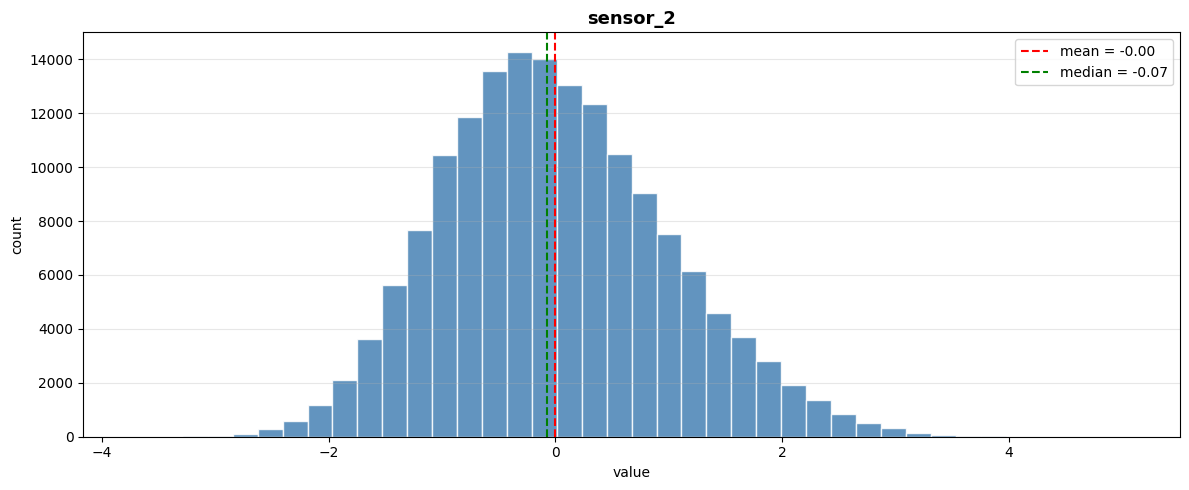

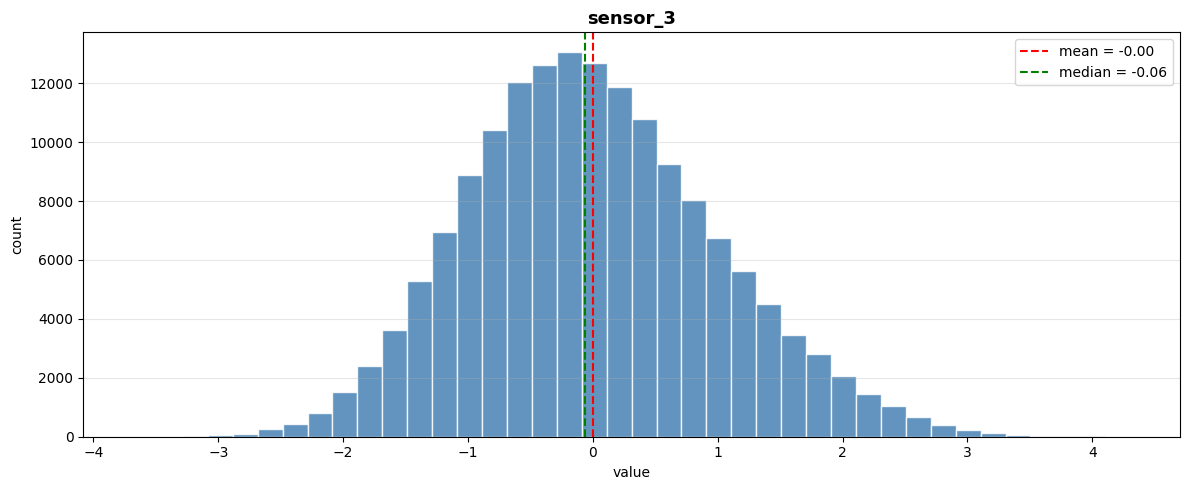

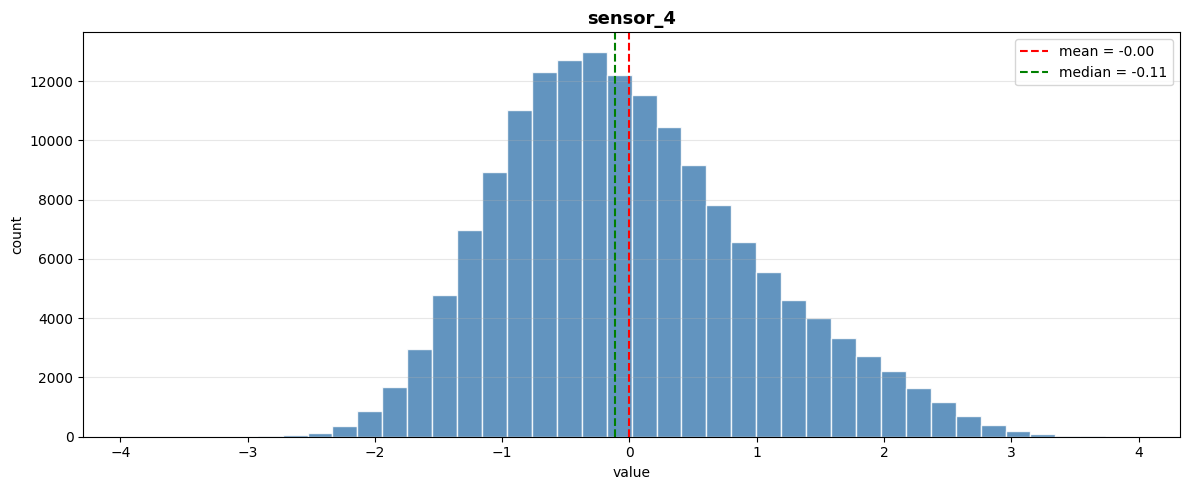

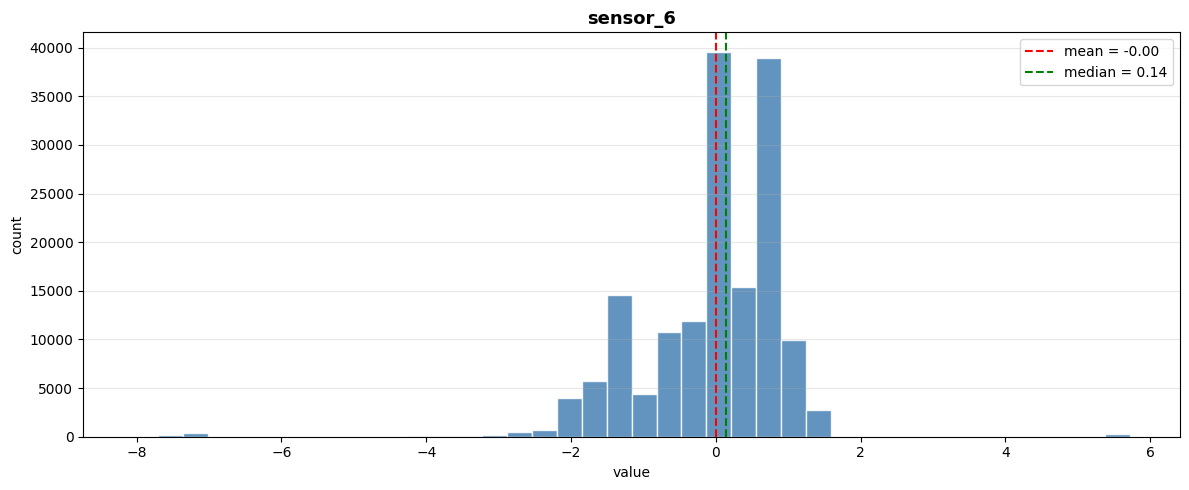

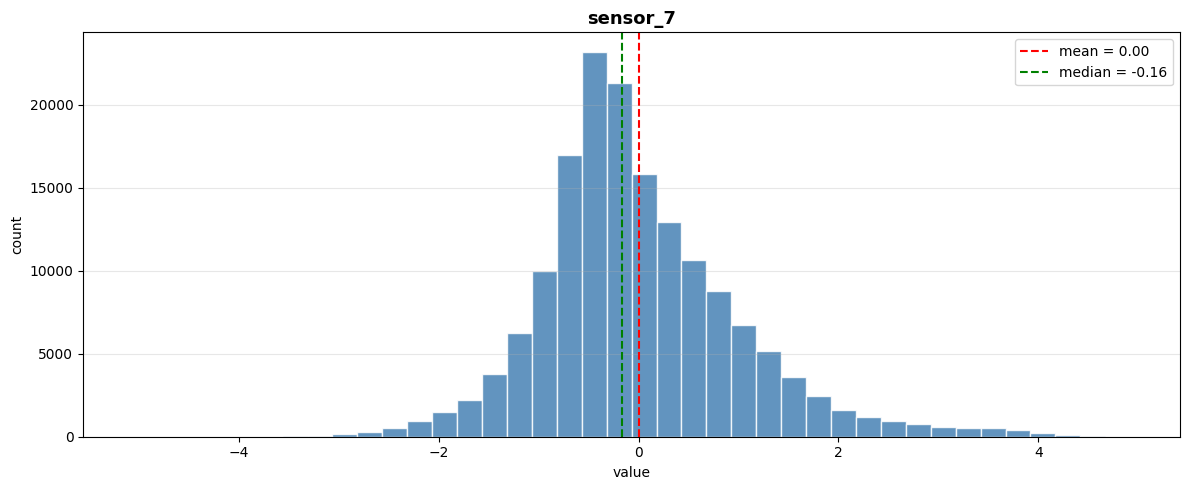

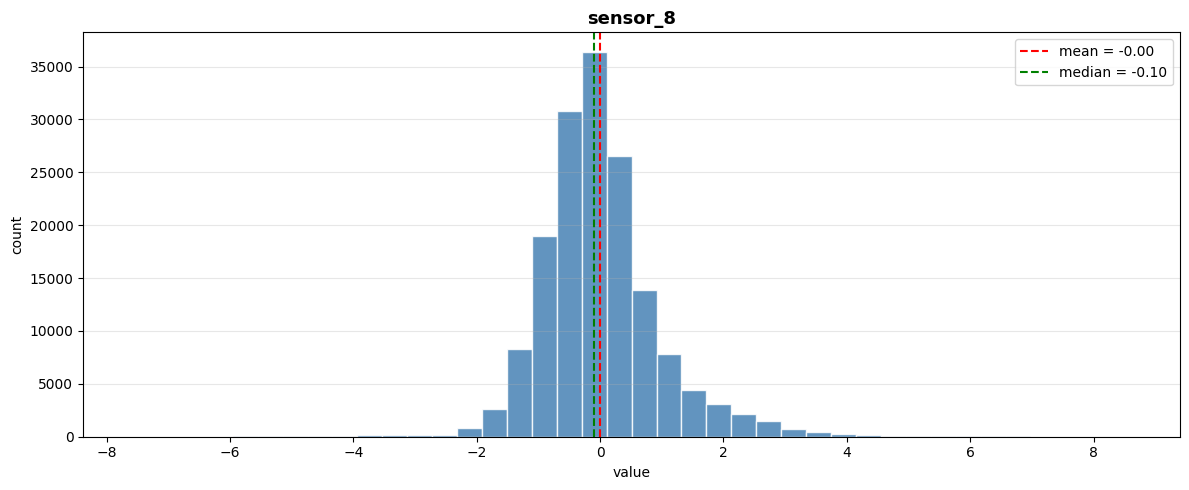

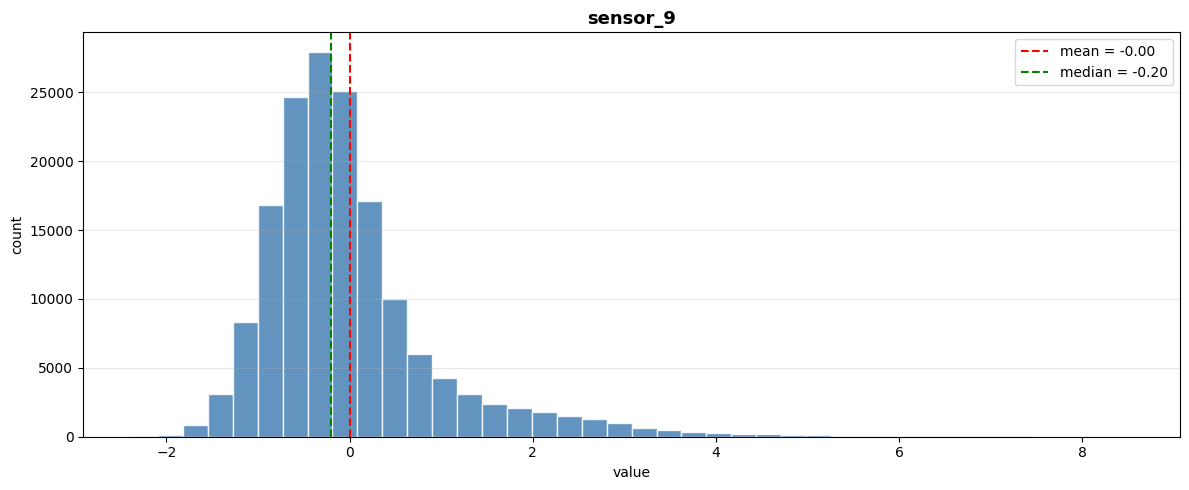

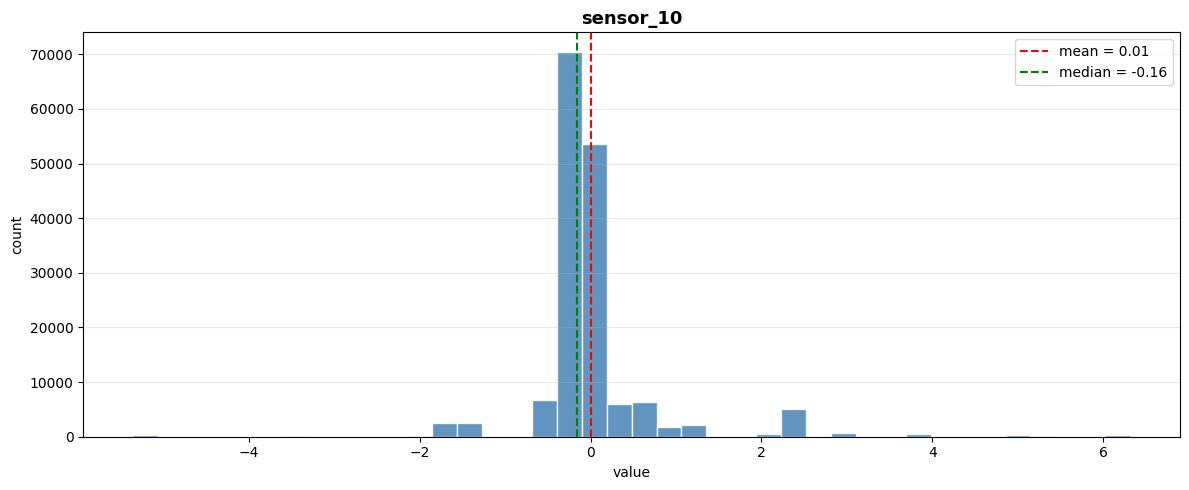

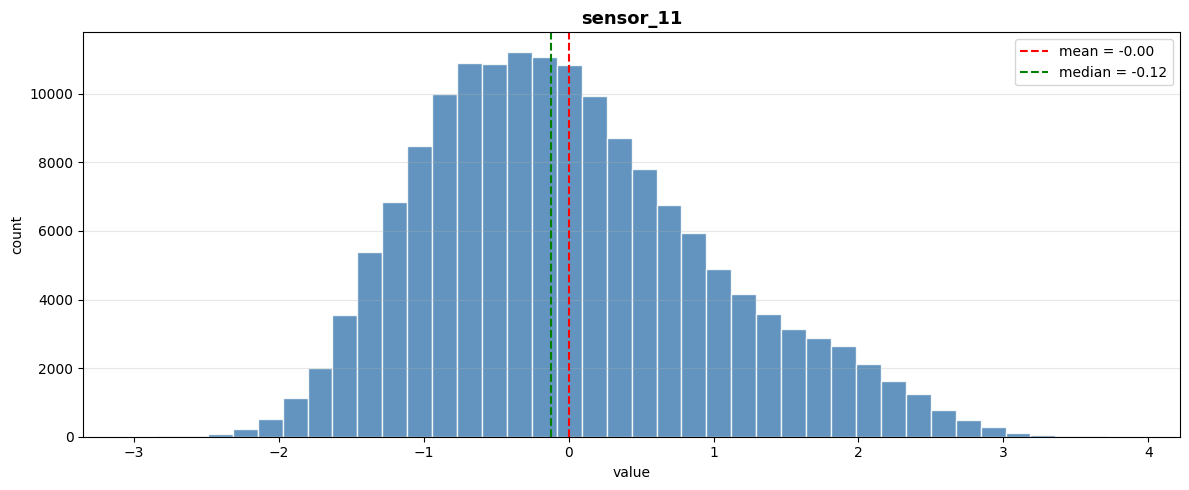

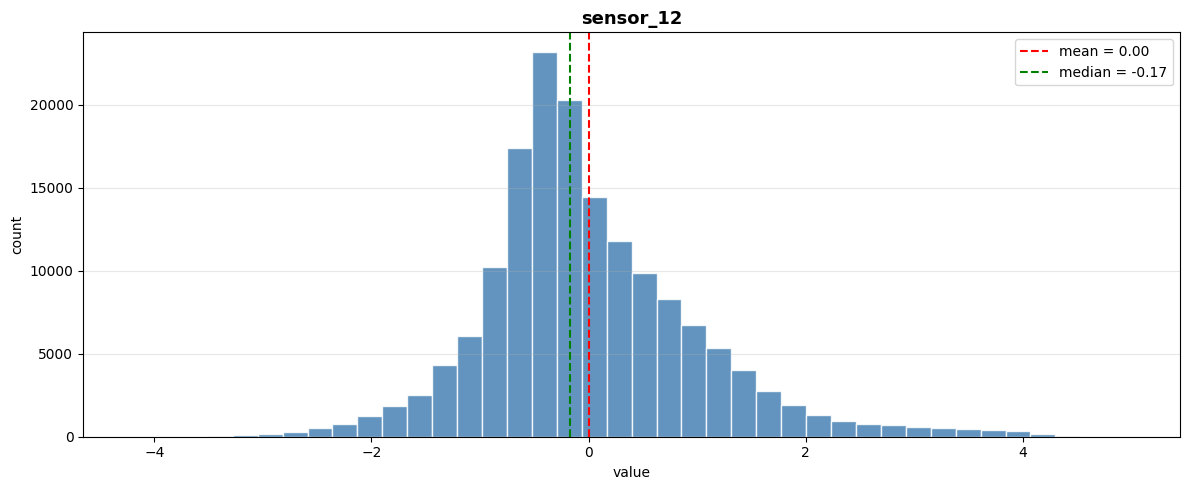

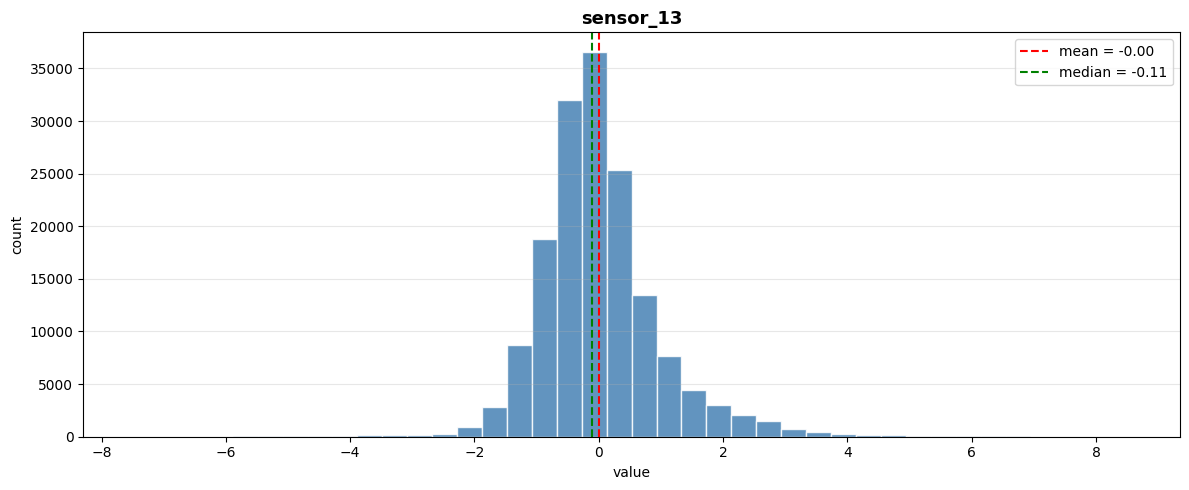

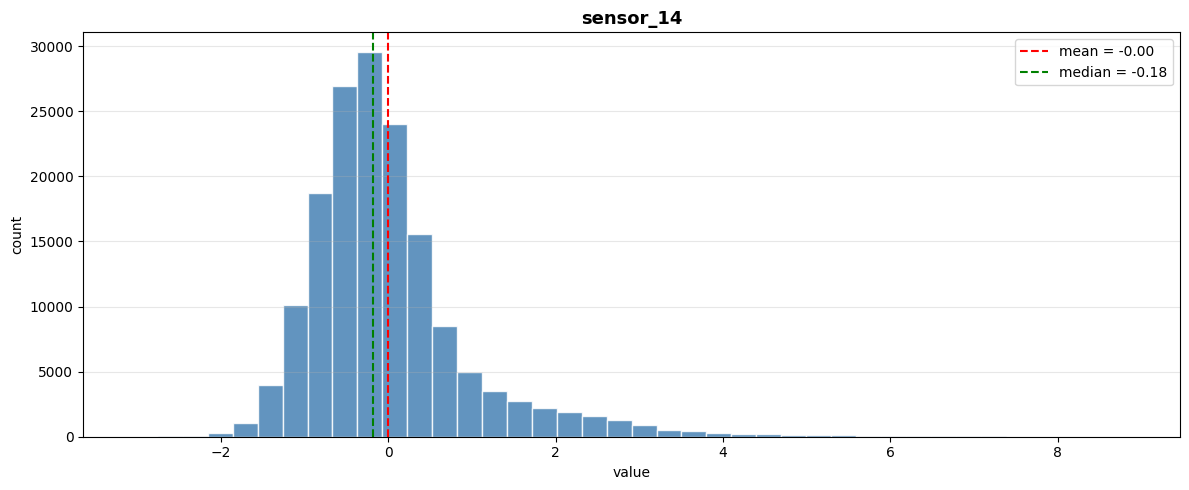

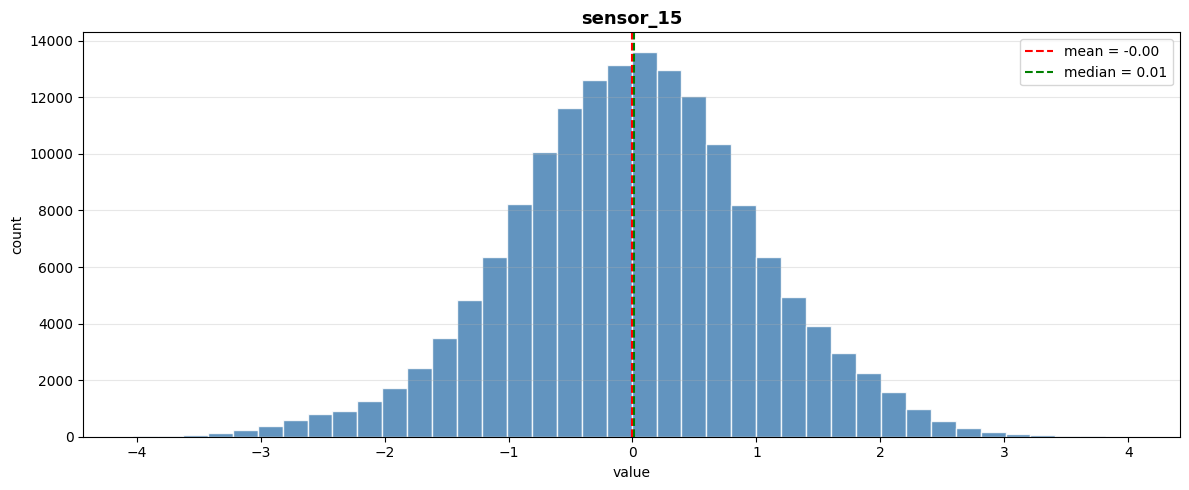

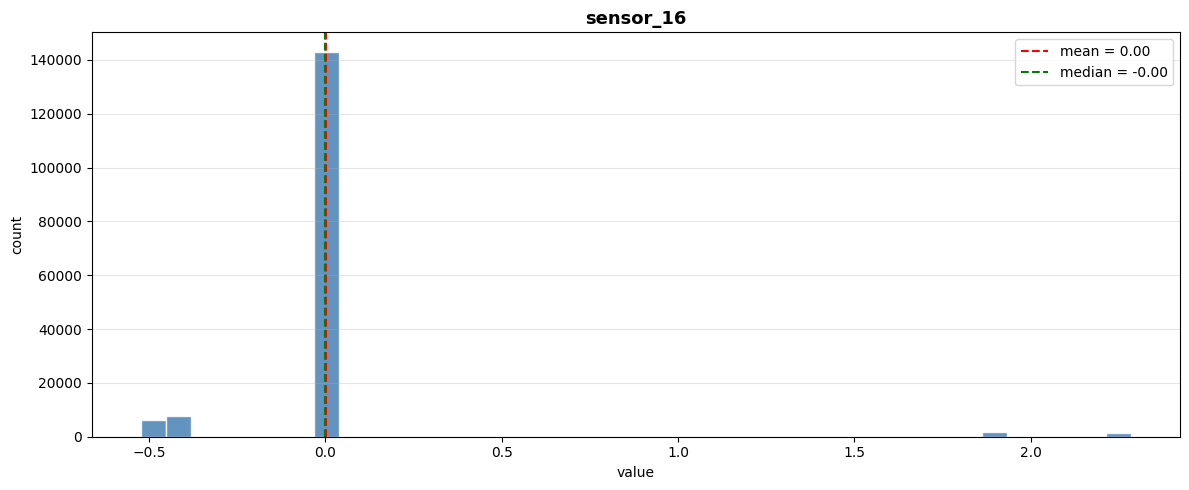

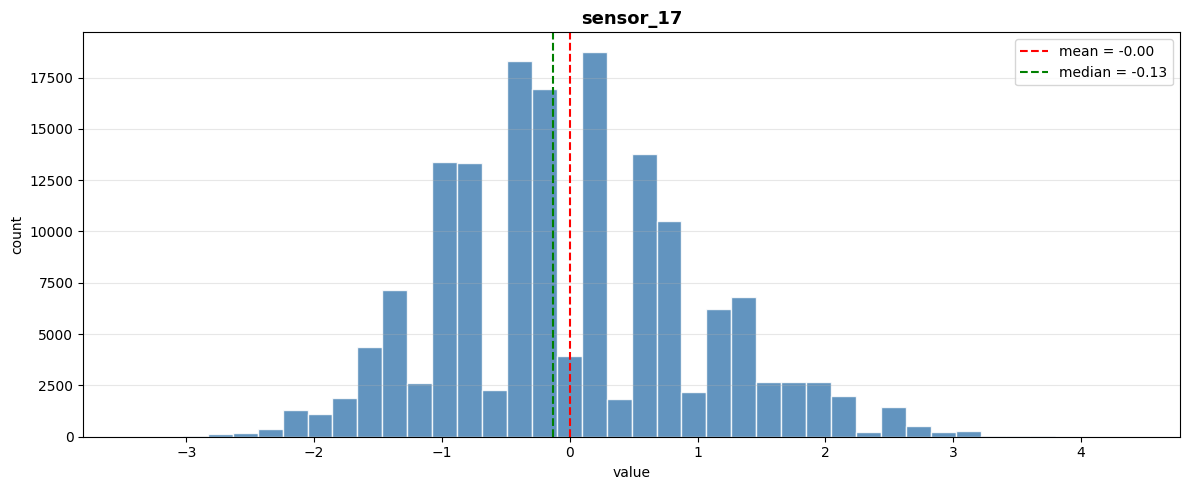

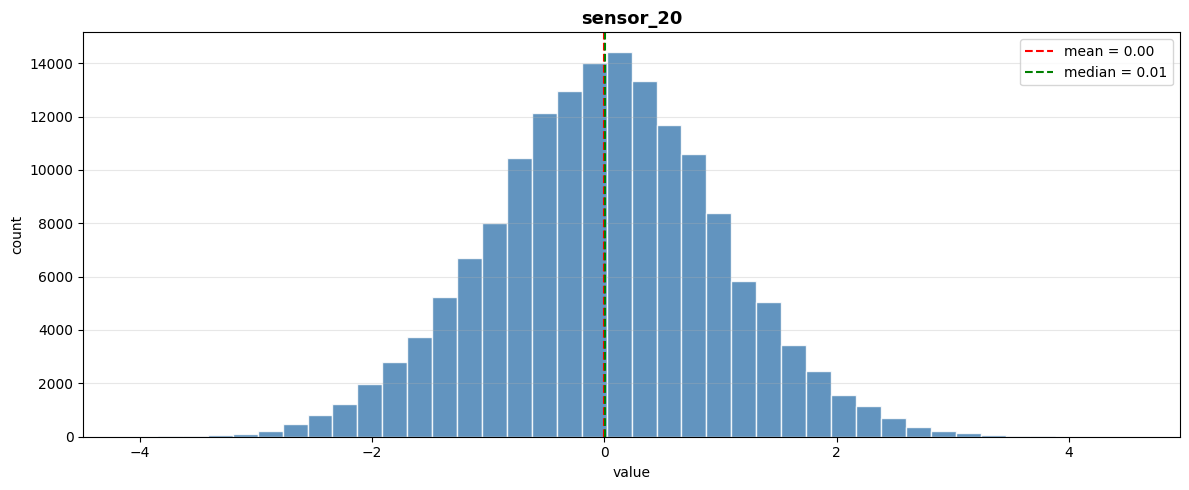

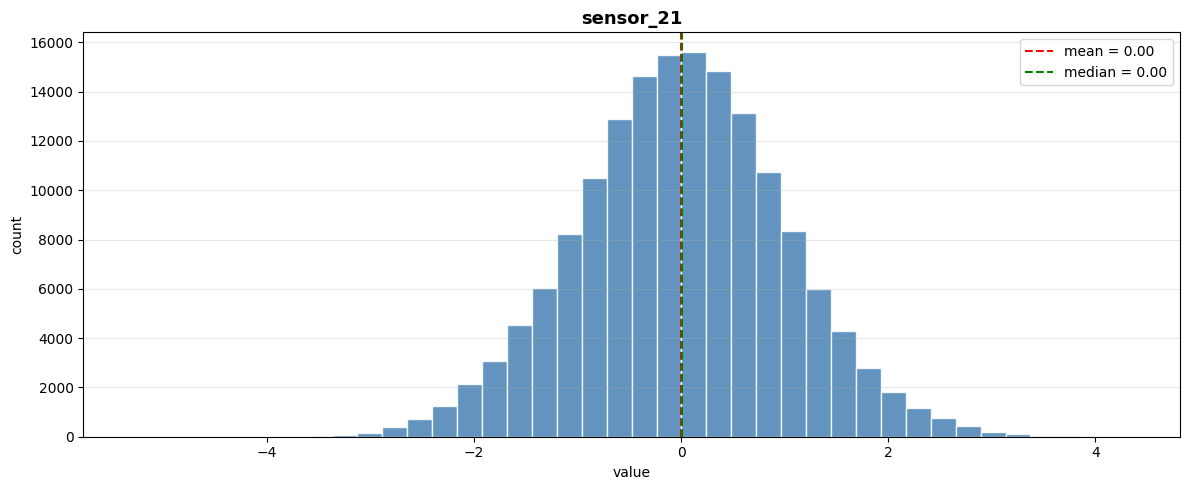

In [ ]:
for col in active_sensors:
    plt.figure(figsize=(12, 5))
    plt.hist(train_all[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)

    mean_val = train_all[col].mean()
    median_val = train_all[col].median()
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'mean = {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'median = {median_val:.2f}')

    plt.title(col, fontsize=13, fontweight='bold')
    plt.xlabel('value')
    plt.ylabel('count')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
print(train_all[sensor_cols].skew().sort_values())


sensor_16   -38.621129
sensor_10    -2.387296
sensor_6     -1.659573
sensor_15    -0.100603
sensor_5      0.000000
sensor_1      0.000000
sensor_19     0.000000
sensor_18     0.000000
sensor_20     0.003318
sensor_21     0.010784
sensor_3      0.279851
sensor_2      0.315968
sensor_17     0.317597
sensor_4      0.455285
sensor_11     0.490290
sensor_7      0.805261
sensor_12     0.828232
sensor_8      0.857166
sensor_13     0.859110
sensor_14     1.980558
sensor_9      2.062476
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

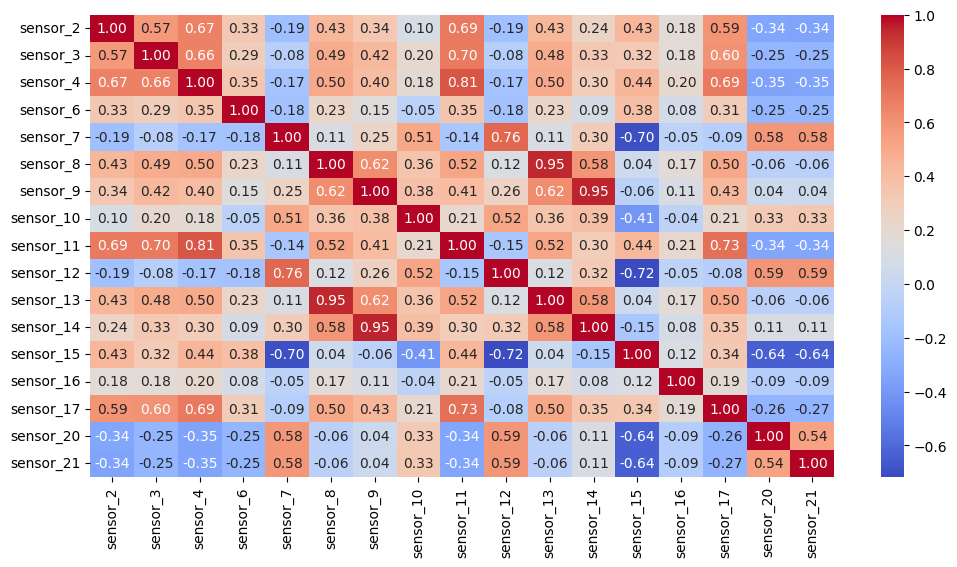

In [ ]:
corr = train_all[active_sensors].corr(numeric_only=True)
plt.figure(figsize=(12,6))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.show



In [ ]:
rul_corr = train_all[sensor_cols].corrwith(train_all['rul']).sort_values(ascending=False)
print(rul_corr)


sensor_20    0.272333
sensor_21    0.270129
sensor_7     0.086288
sensor_12    0.086148
sensor_1    -0.001208
sensor_5    -0.007840
sensor_19   -0.008633
sensor_16   -0.180444
sensor_6    -0.197993
sensor_10   -0.219585
sensor_15   -0.331429
sensor_14   -0.448650
sensor_9    -0.535137
sensor_8    -0.551623
sensor_13   -0.552313
sensor_2    -0.623699
sensor_3    -0.644186
sensor_17   -0.670868
sensor_4    -0.736541
sensor_11   -0.770416
sensor_18         NaN
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 11. Outlier Detection & Removal (IQR method, training data only)

Uses the classic IQR rule (`< Q1 - 1.5*IQR` or `> Q3 + 1.5*IQR` = outlier)
across all `active_sensors`, tallies how many *different* sensors flag each
row, and treats rows flagged by many sensors at once (`> 12`) as genuine
data-quality issues rather than normal variation. Two specific sensors
(`sensor_10`, `sensor_16`) end up with manually-chosen cutoff thresholds
based on eyeballing the boxplots.


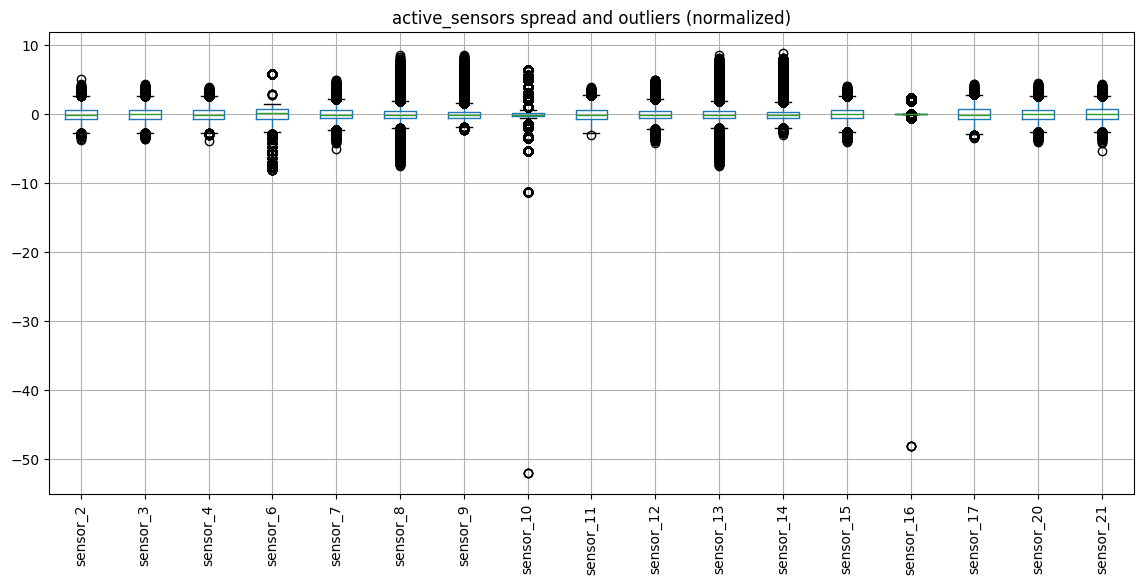

In [ ]:
plt.figure(figsize=(14, 6))
train_all[active_sensors].boxplot(rot=90)
plt.title('active_sensors spread and outliers (normalized)')
plt.show()


In [ ]:
outlier_indices = []
for col in active_sensors:
  q1 = train_all[col].quantile(0.25)
  q3 = train_all[col].quantile(0.75)
  iqr = 1.5*(q3-q1)
  indices = train_all[(train_all[col]<q1-iqr) | (train_all[col]>q3+iqr)].index
  outlier_indices.extend(indices)


In [ ]:
outlier_indices = Counter(outlier_indices)


Counter({181: 3,
         183: 5,
         188: 5,
         197: 1,
         227: 1,
         840: 4,
         846: 5,
         882: 1,
         1280: 3,
         1281: 4,
         1284: 2,
         1560: 5,
         1562: 4,
         1913: 6,
         2130: 2,
         2134: 5,
         2345: 3,
         2708: 7,
         2881: 3,
         2885: 3,
         3295: 4,
         3298: 7,
         3303: 7,
         3561: 3,
         3774: 4,
         3856: 1,
         4150: 3,
         4161: 2,
         4349: 3,
         4730: 4,
         5087: 3,
         5306: 5,
         5492: 1,
         5791: 4,
         6215: 4,
         6218: 5,
         6605: 4,
         6978: 3,
         7635: 4,
         7636: 7,
         7814: 3,
         7824: 5,
         8039: 7,
         8436: 2,
         8440: 7,
         8635: 4,
         8793: 5,
         8822: 1,
         9047: 5,
         9050: 6,
         9493: 3,
         9704: 4,
         9710: 6,
         9889: 4,
         10121: 5,
         10324: 3

In [ ]:
multiple_outlier = [i for i,v in outlier_indices.items() if v > 12]

In [ ]:
multiple_outlier


[138655, 118975, 118978, 100833]

In [ ]:
# train_all[train_all["sensor_10"] < -20]
train_all=train_all[train_all["sensor_10"] >= -10]


In [ ]:
#train_all=train_all.drop(train_all[train_all["sensor_16"] < -20])
train_all=train_all[train_all["sensor_16"] >= -20]


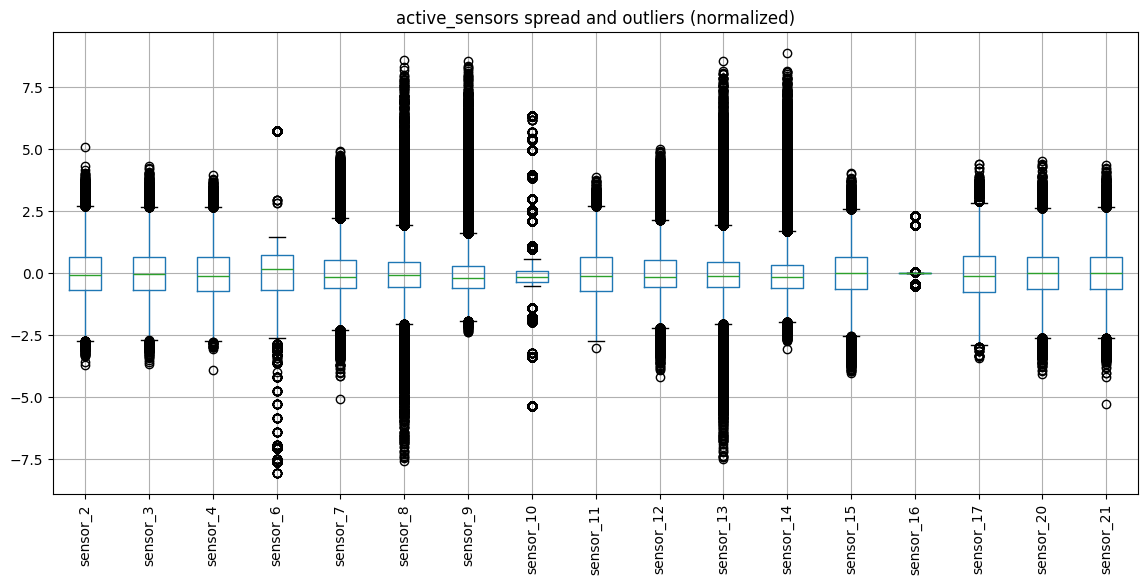

In [ ]:
plt.figure(figsize=(14, 6))
train_all[active_sensors].boxplot(rot=90)
plt.title('active_sensors spread and outliers (normalized)')
plt.show()


## 12. Dimensionality Reduction — PCA

Compresses the 17 `active_sensors` (which are still fairly correlated with
each other, per the VIF/heatmap above) into a smaller set of uncorrelated
principal components. A full PCA is fit first just to see how many
components are needed to explain 95% of the variance, then a final PCA
with **11 components** is fit and used going forward.

PCA is fit on `x_train` only and just `.transform`-ed on `x_test` — again,
no leakage.


In [ ]:
x_train = train_all[active_sensors]
x_test = test_all[active_sensors]


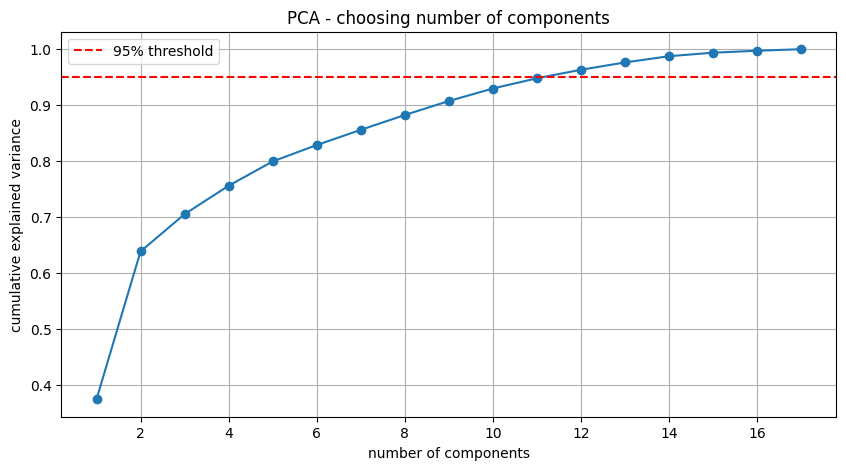

components needed for 95% variance: 12


In [ ]:
pca_full = PCA()
pca_full.fit(x_train)

cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.title('PCA - choosing number of components')
plt.legend()
plt.grid(True)
plt.show()

n_components_95 = np.argmax(cum_variance >= 0.95) + 1
print("components needed for 95% variance:", n_components_95)


In [ ]:
pca_11d = PCA(n_components=11)
x_train_pca_11d = pca_11d.fit_transform(x_train)
x_test_pca_11d = pca_11d.transform(x_test)
PCA11_varince_ratio = pca_11d.explained_variance_ratio_
print(f" total variance captured for pca_11d {np.sum(PCA11_varince_ratio)*100:.2f}")

 total variance captured for pca_11d 94.80


## 13. Target Engineering — `is_degrading` Label & Assembling PCA Features

Creates the binary label that Stage 1 will predict: `is_degrading = 1` if
`rul < 30` (i.e. the engine is within 30 cycles of failure), else `0`
(healthy). This threshold is a design choice — 30 cycles is a reasonably
common "early warning window" choice for this dataset, but it's tunable and
worth mentioning as a deliberate parameter if asked.

Also attaches the 11 PCA components as new columns (`pc1`...`pc11`) on both
`train_all` and `test_all`, so they can be used as Stage 1's input features.


In [ ]:
train_all['is_degrading'] = (train_all['rul'] < 30).astype(int)
test_all['is_degrading'] = (test_all['rul'] < 30).astype(int)


In [ ]:
y_stage1 = train_all["is_degrading"].values


In [ ]:
pca_cols = [f"pc{i+1}" for i in range(11)]
train_all[pca_cols] = x_train_pca_11d
test_all[pca_cols] = x_test_pca_11d


In [ ]:
test_all.columns


Index(['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2',
       'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
       'sensor_21', 'rul', 'dataset', 'n_conditions', 'n_fault_modes',
       'global_unit_id', 'op_condition', 'is_degrading', 'pc1', 'pc2', 'pc3',
       'pc4', 'pc5', 'pc6', 'pc7', 'pc8', 'pc9', 'pc10', 'pc11'],
      dtype='object')

## 14. Train/Validation Split — By Engine, Not By Row

Splits at the **engine level** (`global_unit_id`), not the row level. This
matters a lot: if we split individual rows randomly, cycles from the same
engine could end up in both train and validation, which would leak
information (the model would partly be "tested" on an engine it already
partly saw) and make validation scores look better than they really are.
Splitting by whole engines avoids that.


In [ ]:
engines_id = train_all['global_unit_id'].unique().tolist()
print(len(engines_id))


709


In [ ]:
train_engines, val_engines = train_test_split(engines_id, test_size=0.2, random_state=42)

In [ ]:
train_sub = train_all[train_all['global_unit_id'].isin(train_engines)]
val_sub = train_all[train_all['global_unit_id'].isin(val_engines)]


## 15. Stage 1 Model — Healthy vs Degrading Classifier

**Why two stages?** Instead of asking one model to predict exact RUL for
every engine (including perfectly healthy ones, where RUL is basically
unknowable), we split the problem:
- **Stage 1** (this phase): classify each row as `healthy` or `degrading`
  using the 11 PCA components.
- **Stage 2** (next phase): only for rows Stage 1 says are `degrading`,
  regress the actual RUL value from the raw active sensors. Rows predicted
  `healthy` are simply reported at the RUL cap (125) instead of asking a
  regressor to guess a number that isn't really predictable yet.

The commented-out blocks below show the model comparison and
hyperparameter search that were run to arrive at the final Random Forest
choice — I've kept them (rather than deleting) since they're good evidence
of *why* this model/these hyperparameters were picked, which is useful

In [ ]:
X_train_s1 = train_sub[pca_cols]
y_train_s1 = train_sub['is_degrading'] #healthy(0) / degrading(1)
X_val_s1 = val_sub[pca_cols]
y_val_s1 = val_sub['is_degrading']


# models = {
#     'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
#     'SVM': SVC(class_weight='balanced'),
#     'KNN': KNeighborsClassifier(n_neighbors=5),
#     'Naive Bayes': GaussianNB(),
#     'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
#     'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),  #>best
#     'AdaBoost': AdaBoostClassifier(random_state=42),
#     'Gradient Boosting': GradientBoostingClassifier(random_state=42),
# }

# results = {}
# for name, model in models.items():
#     model.fit(X_train_s1, y_train_s1)
#     preds = model.predict(X_val_s1)
#     print(f"\n--- {name} ---")
#     print(classification_report(y_val_s1, preds, target_names=['healthy', 'degrading']))
#     results[name] = model


In [ ]:
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5, 10],
# }

# best_f1 = 0
# best_params = None
# best_model = None

# for n_estimators in param_grid['n_estimators']:
#     for max_depth in param_grid['max_depth']:
#         for min_samples_split in param_grid['min_samples_split']:

#             model = RandomForestClassifier(
#                 n_estimators=n_estimators,
#                 max_depth=max_depth,
#                 min_samples_split=min_samples_split,
#                 class_weight='balanced',
#                 random_state=42
#             )
#             model.fit(X_train_s1, y_train_s1)
#             preds = model.predict(X_val_s1)

#             f1_degrading = f1_score(y_val_s1, preds, pos_label=1)

#             print(f"n_estimators={n_estimators}, max_depth={max_depth}, "
#                   f"min_samples_split={min_samples_split} -> degrading F1={f1_degrading:.4f}")

#             if f1_degrading > best_f1:
#                 best_f1 = f1_degrading
#                 best_params = (n_estimators, max_depth, min_samples_split)
#                 best_model = model

# print("\nBEST PARAMS:", best_params)
# print("BEST F1 (degrading):", best_f1)
# print("\nFull report for best model:")
# print(classification_report(y_val_s1, best_model.predict(X_val_s1), target_names=['healthy', 'degrading']))

# stage1_model = best_model
# NOTE: this grid search is what produced the winning hyperparameters used below
# (n_estimators=200, max_depth=None, min_samples_split=10).


In [ ]:
stage1_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

stage1_model.fit(X_train_s1, y_train_s1)

val_preds = stage1_model.predict(X_val_s1)

print(classification_report(val_preds, y_val_s1, target_names=['healthy', 'degrading']))


              precision    recall  f1-score   support

     healthy       0.97      0.98      0.98     26523
   degrading       0.87      0.82      0.85      4498

    accuracy                           0.96     31021
   macro avg       0.92      0.90      0.91     31021
weighted avg       0.96      0.96      0.96     31021



## 16. Stage 2 Data Prep — Isolate the Degrading Rows

Stage 2 only ever needs to learn from (and predict on) rows that are
actually degrading — so here we filter both the train and validation
subsets down to `is_degrading == 1` rows, and set up `X`/`y` using the raw
`active_sensors` (not the PCA components — Stage 2 uses the original
sensor features directly).


In [ ]:
train_sub_degrading = train_sub[train_sub['is_degrading'] == 1]
val_sub_degrading = val_sub[val_sub['is_degrading'] == 1]

X_train_s2 = train_sub_degrading[active_sensors]
y_train_s2 = train_sub_degrading['rul']
X_val_s2 = val_sub_degrading[active_sensors]
y_val_s2 = val_sub_degrading['rul']

print("Stage 2 train rows (degrading only):", len(X_train_s2))
print("Stage 2 val rows (degrading only):", len(X_val_s2))


Stage 2 train rows (degrading only): 16989
Stage 2 val rows (degrading only): 4250


## 17. Stage 2 Model — RUL Regressor

Same pattern as Stage 1: an archived comparison across 7 regressors, then
an archived grid search, then the final chosen model (Random Forest
Regressor) trained and evaluated by RMSE. Same recommendation as before —
keep these as a labeled "experimentation log" rather than deleting, since
they justify the final choice.


In [ ]:
# regressors = {
#     'Linear Regression': LinearRegression(),
#     'SVR': SVR(),
#     'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
#     'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
#     'Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=42),
#     'AdaBoost Regressor': AdaBoostRegressor(random_state=42),
#     'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
# }

# for name, model in regressors.items():
#     model.fit(X_train_s2, y_train_s2)
#     preds = model.predict(X_val_s2)
#     rmse = mean_squared_error(y_val_s2, preds) ** 0.5
#     print(f"{name}: RMSE = {rmse:.2f}")


In [ ]:
# param_grid_r = {
#     'n_estimators': [200, 300],
#     'max_depth': [None, 20],
#     'min_samples_split': [2, 10],
# }

# best_rmse = float('inf')
# best_params_r = None
# best_model_r = None

# for n_estimators in param_grid_r['n_estimators']:
#     for max_depth in param_grid_r['max_depth']:
#         for min_samples_split in param_grid_r['min_samples_split']:
#             model = RandomForestRegressor(
#                 n_estimators=n_estimators,
#                 max_depth=max_depth,
#                 min_samples_split=min_samples_split,
#                 random_state=42
#             )
#             model.fit(X_train_s2, y_train_s2)
#             preds = model.predict(X_val_s2)
#             rmse = mean_squared_error(y_val_s2, preds) ** 0.5

#             print(f"n_estimators={n_estimators}, max_depth={max_depth}, "
#                   f"min_samples_split={min_samples_split} -> RMSE={rmse:.2f}")

#             if rmse < best_rmse:
#                 best_rmse = rmse
#                 best_params_r = (n_estimators, max_depth, min_samples_split)
#                 best_model_r = model

# print("\nBEST PARAMS:", best_params_r)
# print("BEST RMSE:", best_rmse)

# stage2_model = best_model_r


In [ ]:
stage2_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

stage2_model.fit(X_train_s2, y_train_s2)

val_preds_s2 = stage2_model.predict(X_val_s2)
rmse_s2 = mean_squared_error(y_val_s2, val_preds_s2) ** 0.5   # RMSE: root mean squared error, in "cycles" units

print(f"Stage 2 (Random Forest Regressor) Validation RMSE: {rmse_s2:.2f}")


Stage 2 (Random Forest Regressor) Validation RMSE: 5.02


## 18. Results Summary — Full Pipeline Recap

These cells don't train anything new — they just re-print a clean summary
of every stage of the pipeline (KMeans clustering, PCA compression, Stage 1
classification, Stage 2 regression, and the combined end-to-end result),


In [ ]:
print("=== KMeans: Operating Condition Clustering ===")
print("Input : op_setting_1, op_setting_2, op_setting_3 (raw)")
print("Output: op_condition (cluster label 0-5)\n")
print("Cluster sizes (train, FD002/FD004):")
print(train_all.loc[mask_train_all, 'op_condition'].value_counts().sort_index())
print("\nInertia (lower = tighter clusters):", kmean.inertia_)


=== KMeans: Operating Condition Clustering ===
Input : op_setting_1, op_setting_2, op_setting_3 (raw)
Output: op_condition (cluster label 0-5)

Cluster sizes (train, FD002/FD004):
op_condition
0    17078
1    17213
2    28853
3    17282
4    17313
5    17199
Name: count, dtype: int64

Inertia (lower = tighter clusters): 0.8791250225626915


In [ ]:
print("=== PCA: Sensor Compression ===")
print(f"Input : {len(active_sensors)} active sensors")
print(f"Output: {pca_11d.n_components_} principal components")
print(f"Variance retained: {np.sum(pca_11d.explained_variance_ratio_)*100:.2f}%")


=== PCA: Sensor Compression ===
Input : 17 active sensors
Output: 11 principal components
Variance retained: 94.80%


In [ ]:
print("=== STAGE 1: RandomForestClassifier ===")
print("Input : 11 PCA components")
print("Output: is_degrading (0 = healthy, 1 = degrading)\n")

print("--- Validation ---")
print(classification_report(y_val_s1, stage1_model.predict(X_val_s1),
                             target_names=['healthy', 'degrading']))


test_all['pred_is_degrading'] = stage1_model.predict(test_all[pca_cols])
print("--- Test set (predicted vs true) ---")
print(classification_report(test_all['is_degrading'], test_all['pred_is_degrading'],
                             target_names=['healthy', 'degrading']))


=== STAGE 1: RandomForestClassifier ===
Input : 11 PCA components
Output: is_degrading (0 = healthy, 1 = degrading)

--- Validation ---
              precision    recall  f1-score   support

     healthy       0.98      0.97      0.98     26771
   degrading       0.82      0.87      0.85      4250

    accuracy                           0.96     31021
   macro avg       0.90      0.92      0.91     31021
weighted avg       0.96      0.96      0.96     31021

--- Test set (predicted vs true) ---
              precision    recall  f1-score   support

     healthy       0.99      0.99      0.99    102482
   degrading       0.67      0.69      0.68      2415

    accuracy                           0.99    104897
   macro avg       0.83      0.84      0.84    104897
weighted avg       0.99      0.99      0.99    104897



In [ ]:
print("=== STAGE 2: RandomForestRegressor ===")
print("Input : 17 active sensors (normalized)")
print("Output: predicted RUL (0-125)\n")

val_rmse = mean_squared_error(y_val_s2, stage2_model.predict(X_val_s2)) ** 0.5
print(f"Validation RMSE (true degrading rows): {val_rmse:.2f}")

test_pred_degrading = test_all[test_all['pred_is_degrading'] == 1]
test_preds = stage2_model.predict(test_pred_degrading[active_sensors])
test_rmse = mean_squared_error(test_pred_degrading['rul'], test_preds) ** 0.5
print(f"Test RMSE (model-predicted degrading rows, n={len(test_pred_degrading)}): {test_rmse:.2f}")


=== STAGE 2: RandomForestRegressor ===
Input : 17 active sensors (normalized)
Output: predicted RUL (0-125)

Validation RMSE (true degrading rows): 5.02
Test RMSE (model-predicted degrading rows, n=2507): 20.03


In [ ]:
print("=== FULL PIPELINE: Stage 1 -> Stage 2 combined ===")
full_preds = np.where(
    test_all['pred_is_degrading'] == 1,
    stage2_model.predict(test_all[active_sensors]),
    rul_cap
)
rmse_full = mean_squared_error(test_all['rul'], full_preds) ** 0.5
print(f"Full end-to-end Test RMSE (all {len(test_all)} test rows): {rmse_full:.2f}")


=== FULL PIPELINE: Stage 1 -> Stage 2 combined ===
Full end-to-end Test RMSE (all 104897 test rows): 26.58


## 19. Save Trained Models

Persists every fitted object needed to reproduce predictions later (without
retraining): the KMeans operating-condition model, the per-condition
scalers, the PCA transformer, and both stage models.


In [ ]:
MODEL_DIR = "../models"   # sibling folder to notebook/ and data/
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(kmean,        os.path.join(MODEL_DIR, "kmeans_model.pkl"))
joblib.dump(scalers,      os.path.join(MODEL_DIR, "scalers.pkl"))
joblib.dump(pca_11d,      os.path.join(MODEL_DIR, "pca_model.pkl"))
joblib.dump(stage1_model, os.path.join(MODEL_DIR, "stage1_model.pkl"))
joblib.dump(stage2_model, os.path.join(MODEL_DIR, "stage2_model.pkl"))

print("Models saved to", MODEL_DIR)


Models saved to ../models


## Summary of Review Notes (Claude's Opinion)

**Real issues worth fixing before you present:**
1. **Bug (Phase 5):** `.unique` is missing parentheses in the per-column
   loop — it prints a method object, not actual values. Either fix to
   `.unique()` or delete the cell (the `value_counts()` loop right before it
   should probably go too — same reason, unreadable output for 21+
   continuous columns).
2. **Bug (Phase 15):** `classification_report(val_preds, y_val_s1, ...)` has
   `y_pred` and `y_true` swapped. Fix the argument order so this cell's
   printed precision/recall match the correct version shown later in Phase
   18.
3. **Design point to be ready to explain (Phase 11):** outlier removal is
   applied to `train_all` only, never `test_all`. Defensible, but call it
   out explicitly in discussion rather than leaving it implicit.
4. **Minor (Phase 9):** the VIF table and the `dead_sensors` list aren't
   directly linked in the code — the drop decision is domain knowledge, not
   a VIF cutoff. Worth one sentence clarifying that when you present it.

**Cosmetic only (candidates for removal, don't affect results):**
bare-variable "debug peek" cells (`train_all`, `mask_train_all`,
`x_train_pca_11d`, `y_stage1`, `train_sub`, etc.), a couple of exact-duplicate
shape checks, and one duplicated import line. All flagged individually
above with `# REVIEW:`.

**Kept on purpose, labeled clearly:** the commented-out model-comparison and
grid-search blocks (Stage 1 and Stage 2) — these are good evidence for
*why* Random Forest and its specific hyperparameters were chosen, which is
worth having on hand if you're asked "why this model?" today.
